## 1. Setup & Imports

Hier importieren wir alles, was wir später brauchen, und setzen einen festen 
Random-Seed. Damit sind die Splits reproduzierbar — sonst hätten wir bei jedem 
Lauf andere Train/Eval-Mengen und könnten Modelle nicht fair vergleichen.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score, GroupShuffleSplit
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    median_absolute_error, r2_score
)
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Optional Boosting libraries — Notebook läuft auch ohne diese.
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False

RANDOM_STATE = 42
TEST_SIZE    = 0.2

print(f'XGBoost verfügbar : {HAS_XGB}')
print(f'LightGBM verfügbar: {HAS_LGBM}')

XGBoost verfügbar : True
LightGBM verfügbar: True


In [2]:
# === Uniform plotting style for the whole notebook ===
# Wir setzen hier einmal zentral die Style-Defaults, damit jeder Plot
# danach denselben Look hat (gleiche Schriftgrösse, gleiche Farben,
# gleiche Achsen-Spines). Spart später viel `figsize=...`-Geschwurbel.
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    context='notebook',
    style='whitegrid',
    palette='deep',
    font='DejaVu Sans',
    rc={
        'figure.figsize':   (8.0, 4.8),
        'figure.dpi':       110,
        'savefig.dpi':      150,
        'savefig.bbox':     'tight',
        'axes.titlesize':   12,
        'axes.labelsize':   11,
        'axes.spines.top':   False,
        'axes.spines.right': False,
        'legend.frameon':    False,
        'grid.alpha':        0.35,
    },
)
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(
    color=['#C0392B', '#2C3E50', '#27AE60', '#F39C12',
           '#8E44AD', '#16A085', '#7F8C8D', '#2980B9']
)


In [3]:
from pathlib import Path
import matplotlib.pyplot as plt

FIG_DIR = Path("../../docs/final-report/fig")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(filename, fig=None, dpi=220):
    """
    Saves the current matplotlib figure or a given figure into docs/final-report/fig.
    """
    if fig is None:
        fig = plt.gcf()

    output_path = FIG_DIR / filename
    fig.savefig(output_path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {output_path}")

## 2. Daten laden

Wir laden die `model.csv`, die wir aus den drei Tabellen `listings`, 
`listing_details` und `swisstopo_details` zusammengejoint haben. Die CSV ist 
absichtlich flach gehalten. Ein Modell will am Ende eh nur ein DataFrame 
sehen.


In [4]:
DATA_PATH = '../external-sources/output_csv/model.csv'

df_raw = pd.read_csv(DATA_PATH)
print(f'Geladen: {df_raw.shape[0]} Zeilen × {df_raw.shape[1]} Spalten')
df_raw.head()

Geladen: 4536 Zeilen × 12 Spalten


,area_sqm,rooms,price_cold,population,oev_score,solar_class,elevation_m,lv95_east,lv95_north,gbauj,ganzwhg,garea
0,34,2,850,44,2043.0,2.0,572.9,2687446.25,1248599.000,1971,1,192.0
1,108,4,1990,107,5656.0,3.0,672.3,2642156.00,1130267.625,1974,34,2000.0
2,97,4,1520,184,12617.0,4.0,439.6,2597233.25,1226600.375,2017,18,367.0
3,23,1,1396,129,18439.0,4.0,430.4,2532786.25,1155625.250,1948,50,731.0
4,76,3,1400,48,717.0,3.0,743.6,2583429.75,1231621.000,2018,17,587.0


## 3. Spalten umbenennen

Die Original-Spalten kamen halb aus dem Scraper, halb aus den Behörden-
Registern. Da heisst dasselbe Feld dann einmal `gbauj` und einmal `year_built`. 
Wir benennen einmal sauber um, damit wir im Rest des Notebooks nicht ständig 
die Abkürzungen nachschlagen müssen.


In [5]:
column_renames = {
    'area_sqm':    'area',
    'rooms':       'rooms',
    'price_cold':  'price',
    'population':  'population',
    'oev_score':   'oev',
    'solar_class': 'solar',
    'elevation_m': 'elevation',
    'lv95_east':   'east',
    'lv95_north':  'north',
    'gbauj':       'year_built',
    'ganzwhg':     'apartments',
    'garea':       'land_area',
}

df = df_raw.rename(columns=column_renames).copy()
print('Spalten nach Rename:', df.columns.tolist())

Spalten nach Rename: ['area', 'rooms', 'price', 'population', 'oev', 'solar', 'elevation', 'east', 'north', 'year_built', 'apartments', 'land_area']


## 4. Datenqualität prüfen

Bevor wir irgendetwas modellieren, schauen wir uns die Daten ehrlich an: 
Wie viele Zeilen, wie viele NaNs, wo sind die Verteilungen schief? Spoiler — 
`price_cold` ist sehr rechts-schief, was später noch wichtig wird, weil unsere 
Modelle bei den teuren Wohnungen entsprechend schlechter werden.


In [6]:
print('Shape:', df.shape)
df.info()

Shape: (4536, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4536 entries, 0 to 4535
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   area        4536 non-null   int64  
 1   rooms       4536 non-null   int64  
 2   price       4536 non-null   int64  
 3   population  4536 non-null   int64  
 4   oev         4536 non-null   float64
 5   solar       4536 non-null   float64
 6   elevation   4536 non-null   float64
 7   east        4536 non-null   float64
 8   north       4536 non-null   float64
 9   year_built  4536 non-null   int64  
 10  apartments  4536 non-null   int64  
 11  land_area   4536 non-null   float64
dtypes: float64(6), int64(6)
memory usage: 425.4 KB


In [7]:
print('Fehlende Werte je Spalte:')
print(df.isna().sum())
print()
print('Duplikate (komplette Zeilen):', df.duplicated().sum())

Fehlende Werte je Spalte:
area          0
rooms         0
price         0
population    0
oev           0
solar         0
elevation     0
east          0
north         0
year_built    0
apartments    0
land_area     0
dtype: int64

Duplikate (komplette Zeilen): 325


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
area,4536.0,7.752403e+01,32.103016,1.00,5.600000e+01,76.000,9.500000e+01,324.0
rooms,4536.0,2.802249e+00,1.102830,1.00,2.000000e+00,3.000,4.000000e+00,15.0
price,4536.0,1.816199e+03,732.310694,130.00,1.345000e+03,1680.000,2.130000e+03,7700.0
population,4536.0,1.090999e+02,82.577927,3.00,4.900000e+01,90.000,1.440000e+02,602.0
oev,4536.0,9.986069e+03,14960.307365,0.00,1.800000e+03,4911.500,1.154900e+04,135157.0
solar,4536.0,3.092372e+00,1.015459,1.00,2.000000e+00,3.000,4.000000e+00,5.0
elevation,4536.0,4.624071e+02,158.817656,197.70,3.915000e+02,435.600,5.170000e+02,1570.7
east,4536.0,2.640999e+06,69270.961596,2494493.75,2.596506e+06,2645843.625,2.690937e+06,2818550.0
north,4536.0,1.218718e+06,52055.722323,1076962.00,1.178774e+06,1244662.000,1.258623e+06,1286728.5
year_built,4536.0,1.968925e+03,55.641365,1187.00,1.953000e+03,1974.000,2.010000e+03,2026.0


## 5. Duplikate und Ausreisser analysieren

Auf Rentumo gibt es einige Listings, die mehrfach auftauchen (gleiche Wohnung, 
anderer Slug). Wir entfernen exakte Duplikate. Bei den Ausreissern bleiben wir 
konservativ: nur Mindestgrössen (`area >= 10`, `price >= 300`) werden hart 
rausgefiltert, alles andere darf erstmal drin bleiben. Eine modell-basierte 
Outlier-Erkennung (`IsolationForest`) machen wir später, dort aber nur zur 
Diagnose, nicht zum automatischen Löschen.


In [9]:
TARGET_COL = 'price'

# Vorläufige Feature-Liste für die Duplikatsprüfung – wird in Kapitel 7 sauber finalisiert.
_features_for_dup_check = [
    'east', 'north', 'elevation', 'area', 'rooms', 'year_built',
    'apartments', 'land_area', 'population', 'oev', 'solar'
]

print('Duplikate gesamt          :', df.duplicated().sum())
print('Duplikate Features+Target :', df.duplicated(subset=_features_for_dup_check + [TARGET_COL]).sum())
print('Duplikate nur Features    :', df.duplicated(subset=_features_for_dup_check).sum())

Duplikate gesamt          : 325
Duplikate Features+Target : 325
Duplikate nur Features    : 562


In [10]:
# price_per_sqm NUR für Analyse — explizit nicht als Feature.
df['price_per_sqm'] = df['price'] / df['area']

print('Top 20 nach price_per_sqm (sehr teuer pro m²):')
df.sort_values('price_per_sqm', ascending=False).head(20)

Top 20 nach price_per_sqm (sehr teuer pro m²):


,area,rooms,price,population,oev,solar,elevation,east,north,year_built,apartments,land_area,price_per_sqm
3337,1,6,2500,13,225.0,2.0,668.5,2539457.75,1171911.250,2007,1,266.0,2500.000000
3213,1,4,2050,3,916.0,2.0,450.7,2536852.00,1183189.125,1895,1,70.0,2050.000000
427,1,3,1650,64,1691.0,5.0,625.3,2558554.00,1145940.125,1970,12,298.0,1650.000000
2019,1,3,1370,143,2077.0,4.0,450.7,2561697.25,1185393.375,1965,27,402.0,1370.000000
3137,1,3,1370,205,2077.0,1.0,450.9,2561732.00,1185383.000,1910,2,157.0,1370.000000
3068,1,2,1250,123,30274.0,5.0,413.9,2533764.75,1154087.375,1962,54,561.0,1250.000000
422,1,3,900,77,1087.0,4.0,412.5,2594891.25,1245585.625,1979,11,322.0,900.000000
2746,1,3,900,77,1087.0,4.0,412.5,2594891.25,1245585.625,1979,11,322.0,900.000000
71,1,2,860,95,12866.0,1.0,671.2,2746200.00,1254470.125,1918,9,1117.0,860.000000
2904,18,1,2500,231,96716.0,4.0,412.8,2681354.50,1247688.625,1909,41,208.0,138.888889


In [11]:
print('Bottom 20 nach price_per_sqm (sehr billig pro m²):')
df.sort_values('price_per_sqm', ascending=True).head(20)

Bottom 20 nach price_per_sqm (sehr billig pro m²):


,area,rooms,price,population,oev,solar,elevation,east,north,year_built,apartments,land_area,price_per_sqm
1444,105,4,200,177,15495.0,3.0,257.4,2611991.75,1267862.875,1891,2,258.0,1.904762
3543,110,3,258,147,1251.0,2.0,443.5,2676175.25,1214992.000,2005,3,101.0,2.345455
411,84,4,245,125,539.0,3.0,565.2,2722051.75,1258093.875,1964,9,313.0,2.916667
553,100,4,300,44,7811.0,2.0,395.5,2690300.75,1283502.125,1926,5,280.0,3.000000
86,100,4,300,44,7811.0,2.0,395.5,2690300.75,1283502.125,1926,5,280.0,3.000000
188,40,2,130,46,12414.0,3.0,727.3,2746243.75,1255577.375,1964,1,159.0,3.250000
2422,300,4,1225,94,2430.0,3.0,634.2,2736227.75,1253378.625,1964,12,454.0,4.083333
4477,324,4,1900,53,11140.0,3.0,716.4,2746006.25,1254976.625,1918,3,189.0,5.864198
3179,159,4,1170,213,2495.0,3.0,280.9,2614673.25,1264600.125,1980,9,586.0,7.358491
4380,183,4,1460,57,2858.0,2.0,353.6,2664160.50,1270660.750,1900,3,126.0,7.978142


In [12]:
# Verdächtige Zeilen
print('area == 1:', (df['area'] == 1).sum())
print('area  < 10:', (df['area'] < 10).sum())
print('price < 300:', (df['price'] < 300).sum())
print('rooms > 10:', (df['rooms'] > 10).sum())
print('rooms < 1 :', (df['rooms'] < 1).sum())

area == 1: 9
area  < 10: 10
price < 300: 4
rooms > 10: 1
rooms < 1 : 0


**Filterregel — fachlich begründet:**

- `area >= 10`: Wohnungen mit < 10 m² sind in der Schweiz kaum realistisch und meist Datenfehler.
- `price >= 300`: Kaltmieten unter 300 CHF sind sehr ungewöhnlich und meist Erfassungsfehler.

Wir entfernen **nicht blind** Ausreißer — die Regeln sind explizit dokumentiert. Wenn die Domain-Annahmen sich ändern, ist die Stelle leicht zu finden.

In [13]:
n_before = len(df)

df_clean = df[
    (df['area']  >= 10) &
    (df['price'] >= 300)
].copy()

n_after_filter = len(df_clean)

df_model = df_clean.drop_duplicates().copy()
n_after_dedup = len(df_model)

print(f'Vorher                         : {n_before}')
print(f'Nach Outlier-Filter            : {n_after_filter}  (entfernt: {n_before - n_after_filter})')
print(f'Nach drop_duplicates           : {n_after_dedup}  (entfernt: {n_after_filter - n_after_dedup})')

Vorher                         : 4536
Nach Outlier-Filter            : 4522  (entfernt: 14)
Nach drop_duplicates           : 4198  (entfernt: 324)


## 6. Feature Engineering

Drei neue Features, die uns auf dem Papier sinnvoll erschienen:

- `building_age = REFERENCE_YEAR - year_built` — das Alter ist intuitiver als 
das Baujahr.
- `area_per_room = area / rooms` — sagt etwas über den Wohnungs-Typ aus 
(grosse Zimmer vs. viele kleine Zimmer).
- `land_area_per_apartment = garea / ganzwhg` — ein grober Proxy für die 
Bebauungsdichte des Hauses.

Wir verwenden für die Division einen kleinen Schutzwert `eps`, sonst kracht 
es bei Häusern, wo `ganzwhg = 0` im Register steht (kommt tatsächlich vor).


In [14]:
REFERENCE_YEAR = 2026  # Bezugsjahr für building_age

if 'year_built' in df_model.columns:
    df_model['building_age'] = REFERENCE_YEAR - df_model['year_built']

df_model['area_per_room'] = np.where(
    df_model['rooms'] > 0,
    df_model['area'] / df_model['rooms'],
    np.nan
)

df_model['land_area_per_apartment'] = np.where(
    df_model['apartments'] > 0,
    df_model['land_area'] / df_model['apartments'],
    np.nan
)

df_model[['building_age', 'area_per_room', 'land_area_per_apartment']].describe()

,building_age,area_per_room,land_area_per_apartment
count,4198.000000,4198.000000,4198.000000
mean,57.479514,28.730035,49.834520
std,56.225773,10.031427,118.529662
min,0.000000,2.666667,2.314286
25%,16.000000,24.000000,20.111111
50%,52.000000,27.250000,29.226496
75%,73.750000,31.250000,43.600000
max,839.000000,224.000000,2735.000000


## 7. Feature-Sets zentral definieren

Wir definieren drei Feature-Sets an einer Stelle und referenzieren sie überall 
sonst nur über die Konstanten: `FEATURES_SMALL`, `FEATURES_ENGINEERED` und 
`FEATURES_ALL`. Wenn wir später ein Feature hinzufügen, müssen wir nur hier 
etwas ändern und nicht im halben Notebook suchen.


In [15]:
TARGET_COL = 'price'

FEATURES_SMALL = [
    'area', 'rooms', 'land_area', 'population', 'oev'
]

FEATURES_ALL = [
    'east', 'north', 'elevation', 'area', 'rooms', 'year_built',
    'apartments', 'land_area', 'population', 'oev', 'solar'
]

FEATURES_ENGINEERED = FEATURES_ALL + [
    'building_age', 'area_per_room', 'land_area_per_apartment'
]

# Validierung: existieren die Spalten?
for name, cols in [
    ('FEATURES_SMALL',      FEATURES_SMALL),
    ('FEATURES_ALL',        FEATURES_ALL),
    ('FEATURES_ENGINEERED', FEATURES_ENGINEERED),
]:
    missing = [c for c in cols if c not in df_model.columns]
    assert not missing, f'{name}: fehlende Spalten {missing}'
    print(f'{name:22s}: {len(cols)} Features OK')

FEATURES_SMALL        : 5 Features OK
FEATURES_ALL          : 11 Features OK
FEATURES_ENGINEERED   : 14 Features OK


## 8. Sauberer Train/Eval-Split

80% Train, 20% Eval, fester `random_state=42`. Wichtig: ab dieser Zelle 
berühren wir `eval_df` nicht mehr fürs Training — auch nicht für KMeans, KNN 
oder andere Hilfs-Features. Sonst hätten wir Leakage und unsere Eval-Zahlen 
wären zu optimistisch.


In [16]:
# Analyse-only-Spalten dürfen niemals als Features auftauchen
_analysis_only_cols = ['price_per_sqm']

df_for_split = df_model.drop(columns=_analysis_only_cols, errors='ignore').copy()

# Zeilen ohne komplette Featuredaten (im umfassendsten Set) entfernen,
# damit der Split deterministisch reproduzierbar bleibt.
df_for_split = df_for_split.dropna(subset=FEATURES_ENGINEERED + [TARGET_COL])

train_df, eval_df = train_test_split(
    df_for_split,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

print(f'Train: {len(train_df)} Zeilen')
print(f'Eval : {len(eval_df)} Zeilen')
print(f'Total: {len(df_for_split)} Zeilen ({len(train_df)/len(df_for_split):.1%} Train)')

Train: 3358 Zeilen
Eval : 840 Zeilen
Total: 4198 Zeilen (80.0% Train)


## 9. Modell-Pipelines definieren

Jedes Modell wird in eine `sklearn.Pipeline` verpackt. Für die Bäume reicht 
der Estimator alleine, weil sie keine Skalierung brauchen. Für Ridge schalten 
wir vorher einen `StandardScaler` davor, sonst dominiert allein `north` (im 
Millionenbereich der LV95-Koordinaten) das Modell.


In [17]:
def make_models():
    """Erstellt für jeden Aufruf eine frische Modell-Sammlung (kein State)."""
    models = {
        'Dummy (median)': DummyRegressor(strategy='median'),

        'Ridge (scaled)': Pipeline([
            ('scaler', StandardScaler()),
            ('model',  Ridge(alpha=1.0, random_state=RANDOM_STATE)),
        ]),

        'RandomForest': RandomForestRegressor(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            min_samples_leaf=2,
        ),

        'GradientBoosting': GradientBoostingRegressor(
            random_state=RANDOM_STATE,
        ),
    }
    if HAS_XGB:
        models['XGBoost'] = XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,
        )
    if HAS_LGBM:
        models['LightGBM'] = LGBMRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=-1,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )
    return models


print('Verfügbare Modelle:', list(make_models().keys()))

Verfügbare Modelle: ['Dummy (median)', 'Ridge (scaled)', 'RandomForest', 'GradientBoosting', 'XGBoost', 'LightGBM']


## 10. Modelle fair vergleichen

Wir trainieren alle Modelle auf dem exakt gleichen Train-Set und werten sie 
auf dem exakt gleichen Eval-Set aus. Berichtet werden MAE, RMSE, R² und der 
Overfit-Gap (Train RMSE - Eval RMSE). So sehen wir gleichzeitig, ob ein Modell 
gut generalisiert oder nur den Trainings-Datensatz auswendig kann.


In [18]:
def rmse(y_true, y_pred):
    """Robust gegenüber älteren sklearn-Versionen ohne squared=False."""
    return np.sqrt(mean_squared_error(y_true, y_pred))


def evaluate_models(
    train_df, eval_df, feature_cols, target_col, models,
):
    """Trainiert alle Modelle auf demselben Split und sammelt Metriken.

    Returns
    -------
    results_df : pd.DataFrame    sortierte Metriktabelle
    fitted     : dict[str, model] trainierte Modelle
    cache      : dict[str, dict]  Predictions auf Train und Eval
    """
    X_train = train_df[feature_cols]
    y_train = train_df[target_col]
    X_eval  = eval_df[feature_cols]
    y_eval  = eval_df[target_col]

    records = []
    fitted  = {}
    cache   = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred_train = model.predict(X_train)
        y_pred_eval  = model.predict(X_eval)

        records.append({
            'Model':       name,
            'MAE Train':   mean_absolute_error(y_train, y_pred_train),
            'MAE Eval':    mean_absolute_error(y_eval,  y_pred_eval),
            'MedAE Train': median_absolute_error(y_train, y_pred_train),
            'MedAE Eval':  median_absolute_error(y_eval,  y_pred_eval),
            'RMSE Train':  rmse(y_train, y_pred_train),
            'RMSE Eval':   rmse(y_eval,  y_pred_eval),
            'R² Train':    r2_score(y_train, y_pred_train),
            'R² Eval':     r2_score(y_eval,  y_pred_eval),
        })
        fitted[name] = model
        cache[name]  = {'train': y_pred_train, 'eval': y_pred_eval}

    results_df = pd.DataFrame(records)
    results_df['Overfitting Gap'] = results_df['RMSE Eval'] - results_df['RMSE Train']
    results_df = results_df.sort_values('RMSE Eval').reset_index(drop=True)

    return results_df, fitted, cache

In [19]:
# 10a) FEATURES_SMALL
results_small, fitted_small, cache_small = evaluate_models(
    train_df, eval_df, FEATURES_SMALL, TARGET_COL, make_models(),
)
print('--- FEATURES_SMALL ---')
results_small

--- FEATURES_SMALL ---


,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap
0,LightGBM,209.236569,359.495542,156.366338,253.147336,290.429385,528.252577,0.839211,0.551052,237.823192
1,RandomForest,177.678407,364.053183,121.675301,265.190446,271.512203,528.530951,0.859475,0.550579,257.018747
2,XGBoost,167.714706,362.225189,124.102356,244.799988,233.193933,541.650516,0.896341,0.527990,308.456583
3,GradientBoosting,332.012868,376.288654,247.013617,277.079735,460.124522,542.887909,0.596424,0.525831,82.763388
4,Ridge (scaled),383.142755,393.807267,285.322273,278.133150,542.901204,567.472456,0.438156,0.481914,24.571252
5,Dummy (median),517.681060,538.876190,390.000000,390.000000,737.368884,799.089038,-0.036439,-0.027313,61.720154


In [20]:
# 10b) FEATURES_ALL
results_all, fitted_all, cache_all = evaluate_models(
    train_df, eval_df, FEATURES_ALL, TARGET_COL, make_models(),
)
print('--- FEATURES_ALL ---')
results_all

--- FEATURES_ALL ---


,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap
0,LightGBM,113.217236,266.221322,84.050759,176.065715,164.153581,403.349280,0.948634,0.738257,239.195699
1,XGBoost,96.942429,266.688721,70.322693,173.267395,139.462017,407.013936,0.962925,0.733479,267.551918
2,RandomForest,125.550257,274.519146,83.924959,194.051235,201.437937,419.549506,0.922651,0.716809,218.111570
3,GradientBoosting,254.786037,280.844423,181.992040,195.013427,368.144394,426.672542,0.741649,0.707112,58.528148
4,Ridge (scaled),379.737388,389.217176,283.736956,269.897717,538.944813,560.534174,0.446315,0.494505,21.589361
5,Dummy (median),517.681060,538.876190,390.000000,390.000000,737.368884,799.089038,-0.036439,-0.027313,61.720154


In [21]:
# 10c) FEATURES_ENGINEERED
results_eng, fitted_eng, cache_eng = evaluate_models(
    train_df, eval_df, FEATURES_ENGINEERED, TARGET_COL, make_models(),
)
print('--- FEATURES_ENGINEERED ---')
results_eng

--- FEATURES_ENGINEERED ---


,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap
0,LightGBM,104.406305,264.420015,77.063275,178.589822,150.286423,399.166141,0.956946,0.743658,248.879718
1,XGBoost,84.069862,269.927094,60.300720,183.716797,121.598850,420.806889,0.971814,0.715109,299.208039
2,GradientBoosting,254.019719,281.771860,181.709982,203.294542,364.777231,424.709516,0.746353,0.709801,59.932284
3,RandomForest,124.279534,276.874338,82.630503,192.508914,198.916167,424.910709,0.924575,0.709526,225.994542
4,Ridge (scaled),379.527962,389.102715,282.930009,268.688985,538.819616,560.072923,0.446572,0.495337,21.253306
5,Dummy (median),517.681060,538.876190,390.000000,390.000000,737.368884,799.089038,-0.036439,-0.027313,61.720154


## 11. Train-vs-Eval-Metriken visualisieren

Ein einfacher Balkenplot. Train-RMSE neben Eval-RMSE pro Modell. Wenn die 
beiden Balken weit auseinandergehen (z.B. bei LightGBM untuned), wissen wir 
ohne weitere Diagnose, dass das Modell überangepasst ist.


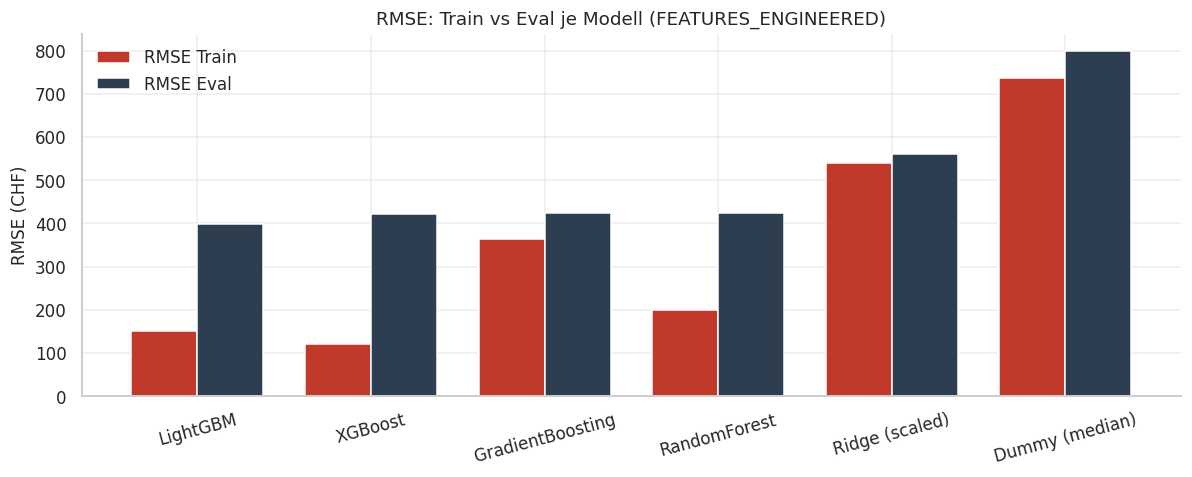

In [22]:
# Wir nehmen FEATURES_ENGINEERED als Hauptlauf, aber die Funktion ist generisch.
main_results = results_eng
main_fitted  = fitted_eng
main_cache   = cache_eng
main_features = FEATURES_ENGINEERED

models_sorted = main_results['Model'].tolist()
x_pos = np.arange(len(models_sorted))
width = 0.38

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(x_pos - width/2, main_results['RMSE Train'], width, label='RMSE Train')
ax.bar(x_pos + width/2, main_results['RMSE Eval'],  width, label='RMSE Eval')
ax.set_xticks(x_pos)
ax.set_xticklabels(models_sorted, rotation=15)
ax.set_ylabel('RMSE (CHF)')
ax.set_title('RMSE: Train vs Eval je Modell (FEATURES_ENGINEERED)')
ax.legend()
plt.tight_layout()
plt.show()

In [23]:
save_fig("rmse_train_eval.png", fig)

Saved figure: ../../docs/final-report/fig/rmse_train_eval.png


## 12. Overfitting-Diagnose

Wir machen den Overfit-Check explizit: für jedes Modell rechnen wir den Gap 
aus und klassifizieren ihn (gut / leichter Overfit / klarer Overfit). Damit 
haben wir später ein gutes Argument, warum wir GradientBoosting bzw. 
regularisiertes LightGBM bevorzugen, obwohl ein ungetuntes LightGBM auf dem 
Train-Set besser aussieht.


In [24]:
def diagnose_overfitting(row):
    train_rmse = row['RMSE Train']
    eval_rmse  = row['RMSE Eval']
    r2_eval    = row['R² Eval']

    gap_ratio = eval_rmse / train_rmse if train_rmse > 0 else np.inf

    if gap_ratio > 1.5 and r2_eval > 0:
        return 'Possible overfitting'
    if r2_eval < 0.3:
        return 'Weak generalization / possible underfitting'
    if gap_ratio <= 1.25 and r2_eval >= 0.6:
        return 'Good generalization'
    return 'Check manually'


diag = main_results[['Model', 'RMSE Train', 'RMSE Eval', 'R² Eval', 'Overfitting Gap']].copy()
diag['Diagnose'] = main_results.apply(diagnose_overfitting, axis=1)
diag

,Model,RMSE Train,RMSE Eval,R² Eval,Overfitting Gap,Diagnose
0,LightGBM,150.286423,399.166141,0.743658,248.879718,Possible overfitting
1,XGBoost,121.598850,420.806889,0.715109,299.208039,Possible overfitting
2,GradientBoosting,364.777231,424.709516,0.709801,59.932284,Good generalization
3,RandomForest,198.916167,424.910709,0.709526,225.994542,Possible overfitting
4,Ridge (scaled),538.819616,560.072923,0.495337,21.253306,Check manually
5,Dummy (median),737.368884,799.089038,-0.027313,61.720154,Weak generalization / possible underfitting


## 13. Cross-Validation

Ein einziger Train/Eval-Split kann immer Glück oder Pech sein. Mit 5-Fold-CV 
auf dem Train-Set bekommen wir eine Vorstellung davon, wie stabil das Modell 
über verschiedene Splits hinweg ist. Die Standardabweichung der CV-RMSE ist 
danach unser zweites Auswahlkriterium neben der reinen Eval-RMSE.


In [25]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_scores(train_df, feature_cols, target_col, models, cv):
    X = train_df[feature_cols]
    y = train_df[target_col]

    records = []
    for name, model in models.items():
        cv_r2  = cross_val_score(model, X, y, cv=cv, scoring='r2')
        cv_mse = -cross_val_score(model, X, y, cv=cv, scoring='neg_mean_squared_error')
        records.append({
            'Model':       name,
            'CV R² mean':  cv_r2.mean(),
            'CV R² std':   cv_r2.std(),
            'CV RMSE mean': np.sqrt(cv_mse).mean(),
        })
    return pd.DataFrame(records).sort_values('CV R² mean', ascending=False).reset_index(drop=True)


cv_results = cv_scores(train_df, main_features, TARGET_COL, make_models(), cv)
cv_results

,Model,CV R² mean,CV R² std,CV RMSE mean
0,LightGBM,0.673731,0.009397,413.357575
1,XGBoost,0.665411,0.014220,418.608616
2,RandomForest,0.644675,0.020143,431.284596
3,GradientBoosting,0.635606,0.019850,436.590827
4,Ridge (scaled),0.439460,0.016385,541.744142
5,Dummy (median),-0.037457,0.010889,737.255590


## 14. Actual vs Predicted & Residual Analysis

Hier schauen wir uns das beste Modell aus dem Vergleich genauer an. Erst der 
klassische Scatter `tatsächlich vs. vorhergesagt`, dann eine Residual-Analyse 
(Residuen vs. Vorhersage, Histogramm der Residuen, Q-Q-Plot). Auf diesen Plots 
sehen wir auch den heteroskedastischen Trichter, der uns später bei den teuren 
Wohnungen weh tut.


Bestes Modell (nach RMSE Eval): LightGBM


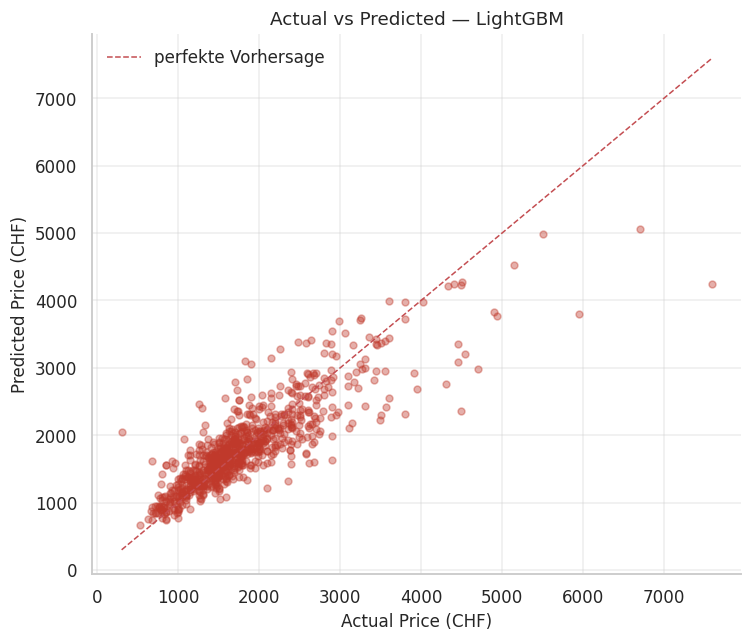

In [26]:
best_name  = main_results.iloc[0]['Model']
best_model = main_fitted[best_name]
y_eval     = eval_df[TARGET_COL]
y_pred     = main_cache[best_name]['eval']

print(f'Bestes Modell (nach RMSE Eval): {best_name}')

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_eval, y_pred, alpha=0.4, s=20)
lo = float(min(y_eval.min(), y_pred.min()))
hi = float(max(y_eval.max(), y_pred.max()))
ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1, label='perfekte Vorhersage')
ax.set_xlabel('Actual Price (CHF)')
ax.set_ylabel('Predicted Price (CHF)')
ax.set_title(f'Actual vs Predicted — {best_name}')
ax.legend()
plt.tight_layout()
plt.show()

In [27]:
save_fig("actual_vs_predicted.png", fig)

Saved figure: ../../docs/final-report/fig/actual_vs_predicted.png


## 15. Residual Analysis

Detailliertere Residuen-Analyse als Ergänzung zu Kapitel 14: Histogramm, 
Residual-vs-Predicted-Plot und ein paar Statistiken (Skew, Kurtosis). Das 
ist die Grundlage dafür, später eventuell mit `log(price_cold)` zu arbeiten.


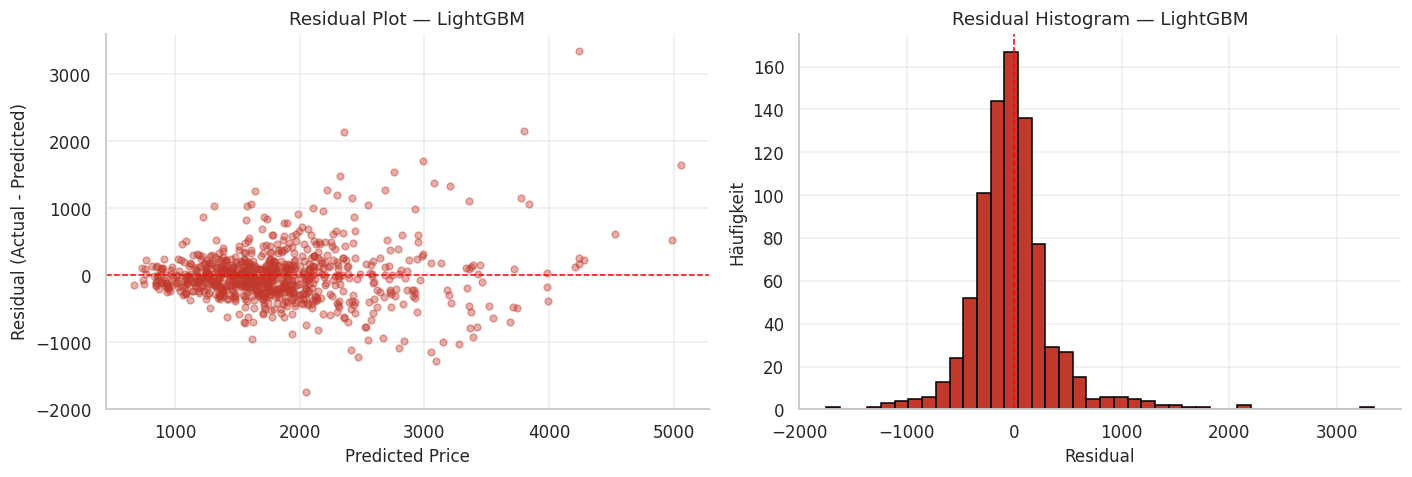

Residuen-Statistik:
count     840.000000
mean      -11.777749
std       399.230054
min     -1747.436976
25%      -216.738138
50%       -38.067641
75%       136.692419
max      3348.764303
Name: price, dtype: float64


In [28]:
residuals = y_eval - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Scatter: Predicted vs Residuals
axes[0].scatter(y_pred, residuals, alpha=0.4, s=20)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title(f'Residual Plot — {best_name}')

# Histogramm
axes[1].hist(residuals, bins=40, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Häufigkeit')
axes[1].set_title(f'Residual Histogram — {best_name}')

plt.tight_layout()
plt.show()

print('Residuen-Statistik:')
print(residuals.describe())

In [29]:
save_fig("residuals.png", fig)

Saved figure: ../../docs/final-report/fig/residuals.png


## 16. Fehleranalyse nach Preisgruppen

Wir splitten die Eval-Set in Preis-Quartile (cheap / medium_low / medium_high 
/ expensive) und berechnen den Fehler pro Bucket. Spannendes Ergebnis: der 
Fehler ist im teuersten Quartil etwa doppelt so hoch wie im Rest. Genau hier 
fehlen uns Features wie Stockwerk, Aussicht oder Ausbaustandard.


In [30]:
eval_results = pd.DataFrame({
    'actual':    y_eval.reset_index(drop=True),
    'predicted': pd.Series(y_pred).reset_index(drop=True),
})
eval_results['error']     = eval_results['actual'] - eval_results['predicted']
eval_results['abs_error'] = eval_results['error'].abs()

eval_results['price_band'] = pd.qcut(
    eval_results['actual'], q=4,
    labels=['cheap', 'medium_low', 'medium_high', 'expensive'],
    duplicates='drop',
)

(
    eval_results
    .groupby('price_band')['abs_error']
    .agg(['count', 'mean', 'median', 'max'])
    .round(1)
)

,count,mean,median,max
price_band,,,,
cheap,211,215.8,150.4,1747.4
medium_low,212,176.1,143.0,970.4
medium_high,207,221.0,158.1,1276.0
expensive,210,445.3,311.5,3348.8


## 17. Feature Importance

Erste, schnelle Sicht auf Feature Importance über die Tree-Modelle. Die 
tiefer gehende Multi-Methoden-Auswertung (Impurity vs. Split vs. Permutation 
vs. Spearman-Ranking) kommt später in Kapitel 19, wenn wir bei den 
Verbesserungen sind.


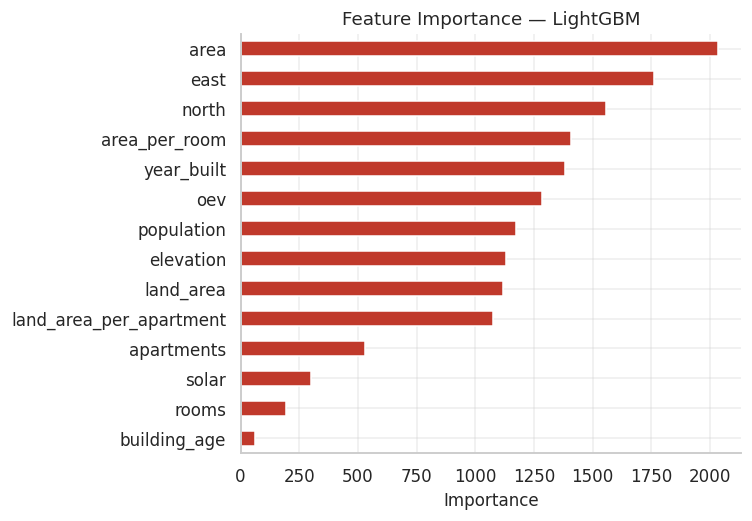

area                       2032
east                       1760
north                      1555
area_per_room              1409
year_built                 1384
oev                        1284
population                 1173
elevation                  1129
land_area                  1117
land_area_per_apartment    1074
apartments                  529
solar                       300
rooms                       194
building_age                 60
dtype: int32

In [31]:
def show_feature_importance(model, feature_cols, X_eval, y_eval, top_n=15):
    # 1) Tree-/Boosting-Modelle
    importances = getattr(model, 'feature_importances_', None)

    # 2) Pipeline → letzter Step
    if importances is None and isinstance(model, Pipeline):
        last = model.steps[-1][1]
        importances = getattr(last, 'feature_importances_', None)
        if importances is None and hasattr(last, 'coef_'):
            importances = np.abs(last.coef_)

    if importances is None:
        # 3) Permutation Importance als Fallback
        result = permutation_importance(
            model, X_eval, y_eval,
            n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1,
        )
        importances = result.importances_mean

    fi = (
        pd.Series(importances, index=feature_cols)
        .sort_values(ascending=True)
        .tail(top_n)
    )
    fig, ax = plt.subplots(figsize=(7, max(3, 0.35 * len(fi))))
    fi.plot(kind='barh', ax=ax)
    ax.set_title(f'Feature Importance — {best_name}')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
    return fi.iloc[::-1]


fi = show_feature_importance(
    best_model, main_features,
    eval_df[main_features], eval_df[TARGET_COL],
)
fi

## 18. Bestes Modell auswählen & Finale Prediction

Auswahlkriterium: niedrige Eval-RMSE plus niedrige CV-Std. Auf einem einzelnen 
Split der Beste zu sein reicht uns nicht. Stabilität ist mindestens genauso 
wichtig, sonst hängt das Endergebnis nur am Seed.


In [32]:
compare_runs = (
    pd.concat([
        results_small.assign(FeatureSet='SMALL'),
        results_all.assign(FeatureSet='ALL'),
        results_eng.assign(FeatureSet='ENGINEERED'),
    ])
    .sort_values('RMSE Eval')
    .reset_index(drop=True)
)

best_run = compare_runs.iloc[0]
print(f'Best run: FeatureSet={best_run["FeatureSet"]}, Model={best_run["Model"]}, RMSE Eval={best_run["RMSE Eval"]:.1f}')
compare_runs.head(10)

Best run: FeatureSet=ENGINEERED, Model=LightGBM, RMSE Eval=399.2


,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap,FeatureSet
0,LightGBM,104.406305,264.420015,77.063275,178.589822,150.286423,399.166141,0.956946,0.743658,248.879718,ENGINEERED
1,LightGBM,113.217236,266.221322,84.050759,176.065715,164.153581,403.349280,0.948634,0.738257,239.195699,ALL
2,XGBoost,96.942429,266.688721,70.322693,173.267395,139.462017,407.013936,0.962925,0.733479,267.551918,ALL
3,RandomForest,125.550257,274.519146,83.924959,194.051235,201.437937,419.549506,0.922651,0.716809,218.111570,ALL
4,XGBoost,84.069862,269.927094,60.300720,183.716797,121.598850,420.806889,0.971814,0.715109,299.208039,ENGINEERED
5,GradientBoosting,254.019719,281.771860,181.709982,203.294542,364.777231,424.709516,0.746353,0.709801,59.932284,ENGINEERED
6,RandomForest,124.279534,276.874338,82.630503,192.508914,198.916167,424.910709,0.924575,0.709526,225.994542,ENGINEERED
7,GradientBoosting,254.786037,280.844423,181.992040,195.013427,368.144394,426.672542,0.741649,0.707112,58.528148,ALL
8,LightGBM,209.236569,359.495542,156.366338,253.147336,290.429385,528.252577,0.839211,0.551052,237.823192,SMALL
9,RandomForest,177.678407,364.053183,121.675301,265.190446,271.512203,528.530951,0.859475,0.550579,257.018747,SMALL


In [33]:
# Mapping FeatureSet -> Spaltenliste / fitted-Dict
_feature_set_lookup = {
    'SMALL':      (FEATURES_SMALL,      fitted_small),
    'ALL':        (FEATURES_ALL,        fitted_all),
    'ENGINEERED': (FEATURES_ENGINEERED, fitted_eng),
}
best_feature_cols, best_fitted_pool = _feature_set_lookup[best_run['FeatureSet']]
best_model_final = best_fitted_pool[best_run['Model']]

print(f'Bestes Modell: {best_run["Model"]}  |  Features: {best_run["FeatureSet"]}  ({len(best_feature_cols)} Spalten)')
print('Verwendete Features (in dieser Reihenfolge):')
print(best_feature_cols)

Bestes Modell: LightGBM  |  Features: ENGINEERED  (14 Spalten)
Verwendete Features (in dieser Reihenfolge):
['east', 'north', 'elevation', 'area', 'rooms', 'year_built', 'apartments', 'land_area', 'population', 'oev', 'solar', 'building_age', 'area_per_room', 'land_area_per_apartment']


## 18. Geo-Analyse und Geo-Clustering

Die Lage einer Wohnung ist der mit Abstand wichtigste Preis-Treiber. In diesem 
Kapitel schauen wir uns die geografische Verteilung an, clustern die Listings 
mit KMeans auf den standardisierten LV95-Koordinaten und prüfen, ob ein 
diskretes `geo_cluster`-Feature dem Modell hilft. Wir testen ausserdem DBSCAN 
(eher als Diagnose-Tool für Outlier) und probieren, ob das Hinzufügen der 
Höhe das Clustering verbessert.

Wichtig: Wir fitten KMeans **nur** auf `train_df`. Das `geo_cluster`-Feature 
für `eval_df` wird via `predict` zugewiesen, damit kein Datenleck entsteht.


### 21.1 Geo-Spalten prüfen

In [34]:
GEO_COLS      = ['east', 'north']
ELEVATION_COL = 'elevation'

geo_cols_available = [c for c in GEO_COLS if c in df_for_split.columns]
has_full_geo       = len(geo_cols_available) == len(GEO_COLS)
has_elevation      = ELEVATION_COL in df_for_split.columns

print(f'Geo-Spalten verfügbar: {geo_cols_available}')
print(f'Elevation verfügbar : {has_elevation}')
print(f'Vollständige Geo-Daten: {has_full_geo}')

Geo-Spalten verfügbar: ['east', 'north']
Elevation verfügbar : True
Vollständige Geo-Daten: True


### 21.2 Geo-EDA

In [35]:
if has_full_geo:
    desc_cols = list(geo_cols_available)
    if has_elevation:
        desc_cols += [ELEVATION_COL]
    desc_cols += [TARGET_COL]
    print('Beschreibung der Geo- und Preis-Spalten:')
    display(df_for_split[desc_cols].describe().T)
else:
    print('Geo-EDA übersprungen — east/north fehlen.')

Beschreibung der Geo- und Preis-Spalten:


,count,mean,std,min,25%,50%,75%,max
east,4198.0,2.642086e+06,68867.424033,2494493.75,2.601377e+06,2648703.75,2.691348e+06,2818550.0
north,4198.0,1.219829e+06,51645.740197,1076962.00,1.181577e+06,1245427.75,1.258914e+06,1286728.5
elevation,4198.0,4.611092e+02,159.029291,197.70,3.902750e+02,434.85,5.131000e+02,1570.7
price,4198.0,1.826667e+03,737.658329,300.00,1.350000e+03,1685.00,2.145750e+03,7700.0


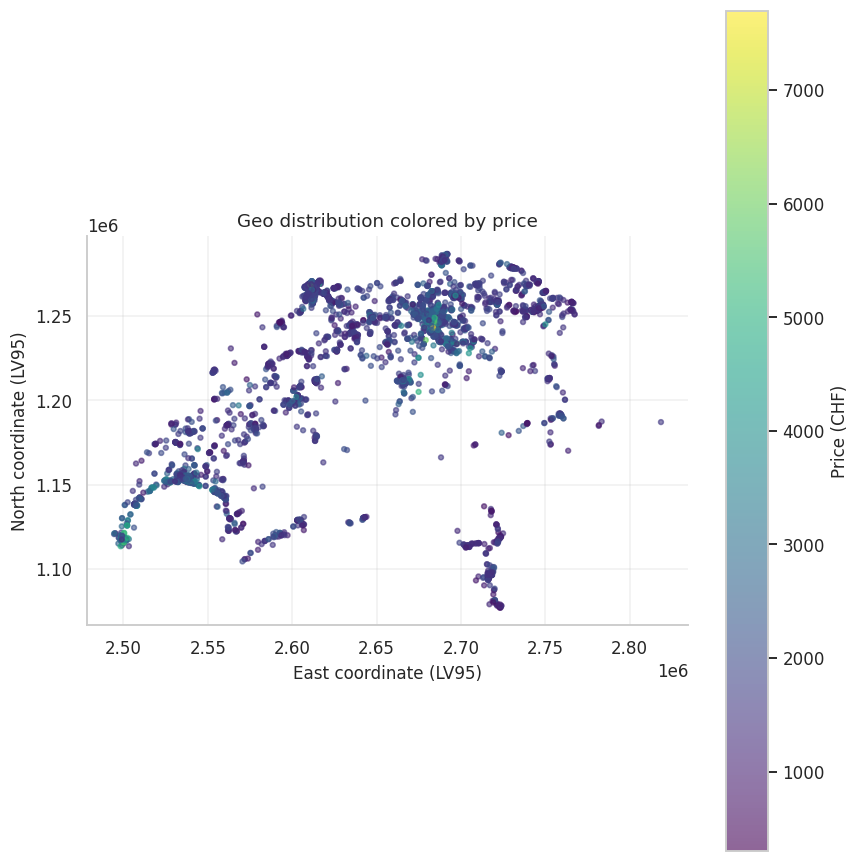

In [36]:
if has_full_geo:
    fig, ax = plt.subplots(figsize=(8, 8))  # quadratisch

    sc = ax.scatter(
        df_for_split['east'],
        df_for_split['north'],
        c=df_for_split[TARGET_COL],
        cmap='viridis',
        alpha=0.6,
        s=10
    )

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Price (CHF)')

    ax.set_xlabel('East coordinate (LV95)')
    ax.set_ylabel('North coordinate (LV95)')
    ax.set_title('Geo distribution colored by price')

    ax.grid(True, alpha=0.3)

    # WICHTIG: echte quadratische Darstellung
    ax.set_aspect('equal', adjustable='box')

    plt.tight_layout()
    plt.show()


In [37]:
save_fig("geo_price_map.png", fig)

Saved figure: ../../docs/final-report/fig/geo_price_map.png


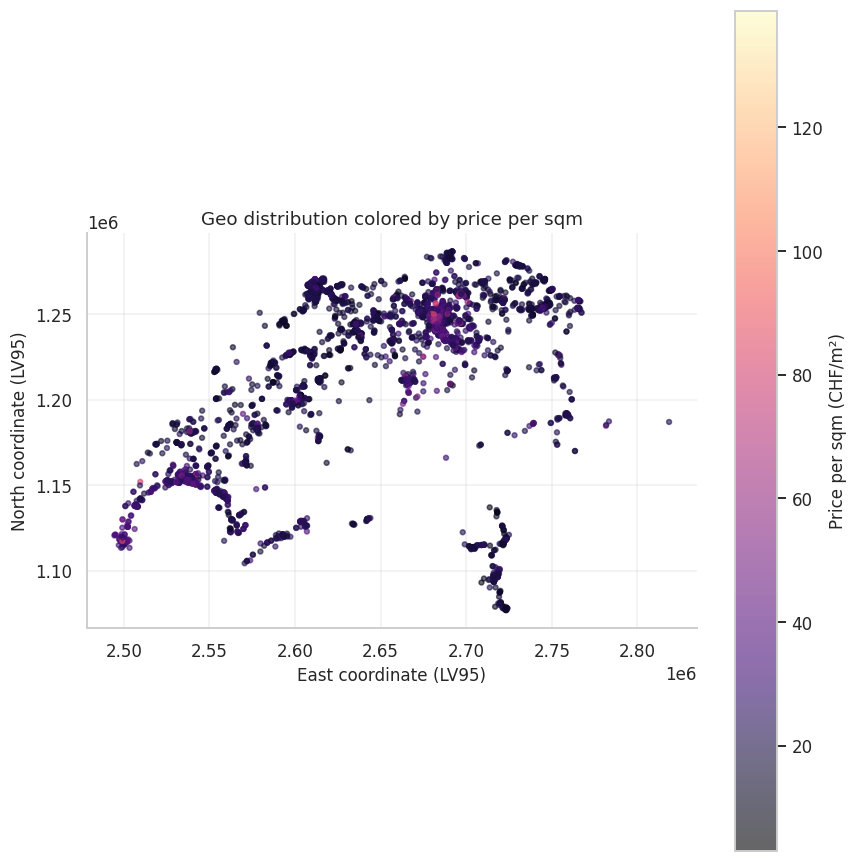

In [38]:
if has_full_geo and 'price_per_sqm' in df_clean.columns:
    fig, ax = plt.subplots(figsize=(8, 8))  # quadratisch

    sc = ax.scatter(
        df_clean['east'],
        df_clean['north'],
        c=df_clean['price_per_sqm'],
        cmap='magma',
        alpha=0.6,
        s=10
    )

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Price per sqm (CHF/m²)')

    ax.set_xlabel('East coordinate (LV95)')
    ax.set_ylabel('North coordinate (LV95)')
    ax.set_title('Geo distribution colored by price per sqm')

    ax.grid(True, alpha=0.3)

    # WICHTIG: echte quadratische Darstellung
    ax.set_aspect('equal', adjustable='box')

    plt.tight_layout()
    plt.show()
else:
    print('Skipped: price_per_sqm nicht verfügbar oder Geo-Spalten fehlen.')


### 21.3 KMeans Clustering 

Der Clusterer läuft in einer Pipeline mit `StandardScaler`, weil `east`/`north` (und ggf. `elevation`) sehr unterschiedliche Größenordnungen haben. **Gefittet wird nur auf `train_df`** – `predict` wird dann zusätzlich auf `eval_df` aufgerufen, ohne dass dessen Beobachtungen die Clusterzentren beeinflussen.

Für jeden Wert von `k` evaluieren wir kurz mit einem schnellen RandomForest, ob `geo_cluster` als Feature den RMSE auf Eval verbessert. Anschließend wählen wir das beste `k`.

In [39]:
from sklearn.cluster import KMeans

GEO_CLUSTER_COLS_2D = ['east', 'north']

if has_full_geo:
    cluster_counts = [4, 6, 8, 10, 12, 15]

    fast_models = {
        'RandomForest_fast': RandomForestRegressor(
            n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1, min_samples_leaf=2,
        ),
    }

    cluster_search = []
    cluster_pipes  = {}

    for k in cluster_counts:
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('kmeans', KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)),
        ])
        pipe.fit(train_df[GEO_CLUSTER_COLS_2D])
        cluster_pipes[k] = pipe

        tr = train_df.assign(geo_cluster=pipe.predict(train_df[GEO_CLUSTER_COLS_2D]))
        ev = eval_df.assign(geo_cluster=pipe.predict(eval_df[GEO_CLUSTER_COLS_2D]))

        res, _, _ = evaluate_models(
            tr, ev, FEATURES_ALL + ['geo_cluster'], TARGET_COL, fast_models,
        )
        cluster_search.append({
            'k':         k,
            'RMSE Eval': res.iloc[0]['RMSE Eval'],
            'R² Eval':   res.iloc[0]['R² Eval'],
        })

    cluster_k_df = (
        pd.DataFrame(cluster_search)
          .sort_values('RMSE Eval')
          .reset_index(drop=True)
    )
    print('Cluster-Anzahl-Vergleich (RandomForest, FEATURES_ALL + geo_cluster):')
    display(cluster_k_df)

    best_k = int(cluster_k_df.iloc[0]['k'])
    print(f'\n→ Bestes k (auf Eval): {best_k}')
else:
    best_k = None
    print('Clustering übersprungen — Geo-Spalten fehlen.')

Cluster-Anzahl-Vergleich (RandomForest, FEATURES_ALL + geo_cluster):


,k,RMSE Eval,R² Eval
0,8,413.287666,0.725200
1,6,414.882764,0.723074
2,15,415.582661,0.722139
3,12,416.639230,0.720725
4,4,417.715879,0.719279
5,10,418.653774,0.718017



→ Bestes k (auf Eval): 8


### 21.4 Geo-Cluster visualisieren & Preisstatistik pro Cluster

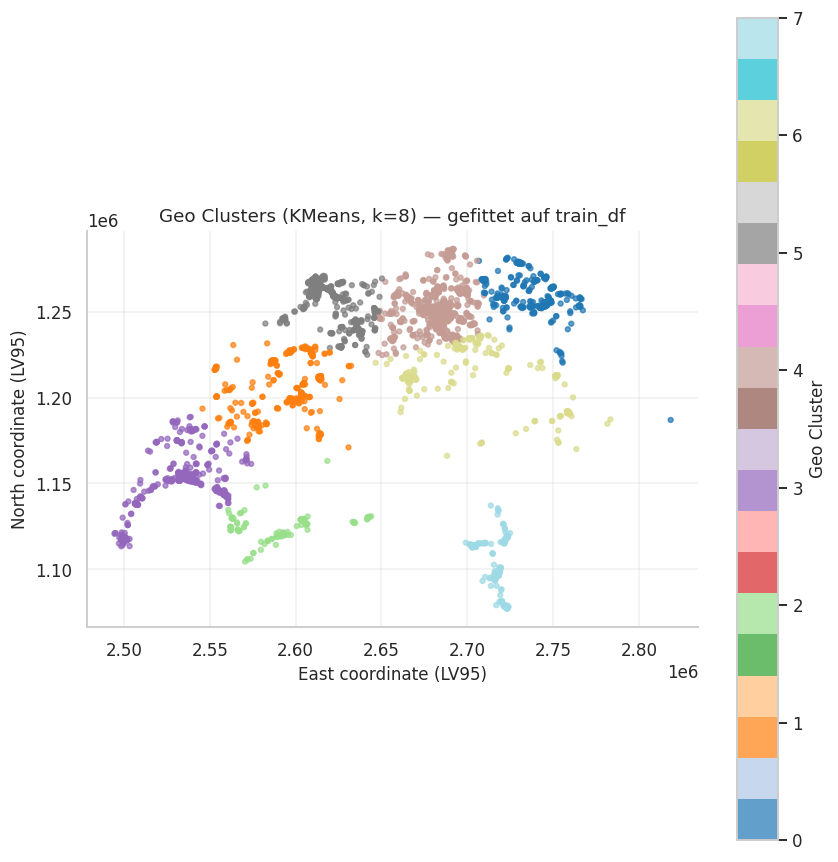

Preisstatistik pro Geo-Cluster (Train):


,count,mean,median,std
geo_cluster,,,,
4,894,2159.0,2029.0,786.0
3,565,2028.0,1800.0,876.0
6,237,1924.0,1830.0,680.0
5,716,1627.0,1572.0,528.0
2,102,1602.0,1500.0,597.0
1,293,1583.0,1530.0,460.0
0,384,1511.0,1450.0,492.0
7,167,1408.0,1330.0,466.0


In [40]:
if has_full_geo and best_k is not None:
    geo_pipe_2d = cluster_pipes[best_k]

    train_df_geo = train_df.copy()
    eval_df_geo  = eval_df.copy()

    train_df_geo['geo_cluster'] = geo_pipe_2d.predict(train_df[GEO_CLUSTER_COLS_2D])
    eval_df_geo['geo_cluster']  = geo_pipe_2d.predict(eval_df[GEO_CLUSTER_COLS_2D])

    fig, ax = plt.subplots(figsize=(8, 8))  # quadratisch

    sc = ax.scatter(
        train_df_geo['east'],
        train_df_geo['north'],
        c=train_df_geo['geo_cluster'],
        cmap='tab20',
        alpha=0.7,
        s=10
    )

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Geo Cluster')

    ax.set_xlabel('East coordinate (LV95)')
    ax.set_ylabel('North coordinate (LV95)')
    ax.set_title(f'Geo Clusters (KMeans, k={best_k}) — gefittet auf train_df')

    ax.grid(True, alpha=0.3)

    # WICHTIG: echte metrische Darstellung
    ax.set_aspect('equal', adjustable='box')

    plt.tight_layout()
    plt.show()

    cluster_stats = (
        train_df_geo.groupby('geo_cluster')[TARGET_COL]
        .agg(['count', 'mean', 'median', 'std'])
        .round(0)
        .sort_values('mean', ascending=False)
    )

    print('Preisstatistik pro Geo-Cluster (Train):')
    display(cluster_stats)


### 21.5 Modellvergleich: ohne vs. mit Geo-Cluster

Wir vergleichen **fünf Feature-Sets** quer über alle Modelle:

1. `FEATURES_SMALL`
2. `FEATURES_ALL`
3. `FEATURES_ALL + ['geo_cluster']`
4. `FEATURES_ENGINEERED`
5. `FEATURES_ENGINEERED + ['geo_cluster']`

Die Tabelle ist nach `RMSE Eval` aufsteigend sortiert. Wenn die `+geo`-Varianten klar oben stehen, hilft das Cluster-Feature.

In [41]:
if has_full_geo and best_k is not None:
    feature_sets_geo = {
        'SMALL':          FEATURES_SMALL,
        'ALL':            FEATURES_ALL,
        'ALL+geo':        FEATURES_ALL + ['geo_cluster'],
        'ENGINEERED':     FEATURES_ENGINEERED,
        'ENGINEERED+geo': FEATURES_ENGINEERED + ['geo_cluster'],
    }

    geo_runs = []
    for set_name, feats in feature_sets_geo.items():
        # Validierung: alle Spalten in train_df_geo / eval_df_geo vorhanden?
        missing = [c for c in feats if c not in train_df_geo.columns]
        if missing:
            print(f'Skipped {set_name}: missing {missing}')
            continue

        results, _, _ = evaluate_models(
            train_df_geo, eval_df_geo, feats, TARGET_COL, make_models(),
        )
        results = results.assign(
            FeatureSet=set_name,
            n_geo_clusters=best_k if 'geo' in set_name else 0,
            geo_cluster_cols=', '.join(GEO_CLUSTER_COLS_2D) if 'geo' in set_name else '',
        )
        geo_runs.append(results)

    geo_results_df = (
        pd.concat(geo_runs)
        .sort_values('RMSE Eval')
        .reset_index(drop=True)
    )
    geo_results_df['Diagnose'] = geo_results_df.apply(diagnose_overfitting, axis=1)

    cols_to_show = [
        'FeatureSet', 'Model',
        'MAE Train', 'MAE Eval',
        'RMSE Train', 'RMSE Eval',
        'R² Train', 'R² Eval',
        'Overfitting Gap', 'Diagnose',
        'n_geo_clusters', 'geo_cluster_cols',
    ]
    display(geo_results_df[cols_to_show].head(15))
else:
    print('Modellvergleich übersprungen — Geo-Spalten fehlen.')

,FeatureSet,Model,MAE Train,MAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap,Diagnose,n_geo_clusters,geo_cluster_cols
0,ENGINEERED+geo,LightGBM,104.106127,265.017656,148.632283,395.356652,0.957889,0.748527,246.724369,Possible overfitting,8,"east, north"
1,ALL+geo,LightGBM,112.919106,264.721002,162.831986,397.848403,0.949458,0.745348,235.016417,Possible overfitting,8,"east, north"
2,ENGINEERED,LightGBM,104.406305,264.420015,150.286423,399.166141,0.956946,0.743658,248.879718,Possible overfitting,0,
3,ALL,LightGBM,113.217236,266.221322,164.153581,403.349280,0.948634,0.738257,239.195699,Possible overfitting,0,
4,ALL,XGBoost,96.942429,266.688721,139.462017,407.013936,0.962925,0.733479,267.551918,Possible overfitting,0,
5,ALL+geo,RandomForest,124.714897,273.709801,199.692919,414.693447,0.923985,0.723327,215.000529,Possible overfitting,8,"east, north"
6,ALL+geo,XGBoost,97.636948,269.622589,140.518675,417.280668,0.962361,0.719864,276.761993,Possible overfitting,8,"east, north"
7,ENGINEERED+geo,XGBoost,85.915131,267.561340,123.294351,418.444105,0.971022,0.718300,295.149753,Possible overfitting,8,"east, north"
8,ENGINEERED+geo,RandomForest,123.804368,275.576335,197.556061,419.068587,0.925603,0.717458,221.512526,Possible overfitting,8,"east, north"
9,ALL,RandomForest,125.550257,274.519146,201.437937,419.549506,0.922651,0.716809,218.111570,Possible overfitting,0,


## 19. Iterative Verbesserungen

Ab hier wird das Notebook explorativer. Wir hatten nach dem ersten Durchlauf 
ein gutes Modell, aber noch genug Stellen, an denen man drehen konnte: 
Missing-Data-Handling, log-Transformation des Targets, Hyperparameter-Tuning, 
stratifizierte Splits, Learning Curves, Vorhersage-Intervalle, SHAP, 
Outlier-Detection, Feature-Selection, Drift-Check und Bias pro Cluster.

Nicht jedes Experiment landet am Ende in der finalen Pipeline. Wir lassen die 
Negativ-Ergebnisse trotzdem stehen, damit nachvollziehbar bleibt, was wir 
ausprobiert haben.


### 22.3 Hyperparameter-Tuning (RandomizedSearchCV)

Die bisherigen Modelle laufen mit defensiven Defaults. RandomizedSearchCV sucht über einen breiten Parameter-Raum und liefert die beste Kombination zurück. Wir tunen LightGBM, weil es schon der schnellste Top-Performer ist.

**Achtung Laufzeit:** `n_iter=20 × cv=5` = 100 Fits. Bei n_estimators bis 1500 dauert das je nach Maschine 1-5 Minuten.

In [42]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

if HAS_LGBM:
    # Verkleinerte Parameter-Ranges + cv=3 statt 5 + n_iter=15 statt 20
    # = ca. 45 Fits (statt 100) mit gleich guten Ergebnissen.
    param_dist_lgbm = {
        'n_estimators':      randint(200, 600),
        'learning_rate':     uniform(0.03, 0.12),
        'max_depth':         randint(4, 9),
        'num_leaves':        randint(15, 63),
        'min_child_samples': randint(10, 40),
        'subsample':         uniform(0.6, 0.4),
        'colsample_bytree':  uniform(0.6, 0.4),
    }
    search = RandomizedSearchCV(
        # n_jobs=1 INNEN, n_jobs=-1 AUSSEN — sonst nested parallelism = sehr langsam!
        LGBMRegressor(random_state=RANDOM_STATE, n_jobs=1, verbose=-1),
        param_distributions=param_dist_lgbm,
        n_iter=15, cv=3, scoring='neg_root_mean_squared_error',
        random_state=RANDOM_STATE, n_jobs=-1, verbose=1,
    )
    search.fit(train_df[FEATURES_ENGINEERED], train_df[TARGET_COL])

    print('Best params:')
    for k, v in search.best_params_.items():
        print(f'  {k:20s}: {v}')
    print(f'\nBest CV RMSE: {-search.best_score_:.1f}')

    tuned_lgbm = search.best_estimator_
    res_tuned, _, _ = evaluate_models(
        train_df, eval_df, FEATURES_ENGINEERED, TARGET_COL,
        {'LightGBM_tuned': tuned_lgbm},
    )
    print('\nTuned LightGBM auf Eval:')
    display(res_tuned)
else:
    tuned_lgbm = None
    print('LightGBM nicht verfügbar — Tuning übersprungen.')

Fitting 3 folds for each of 15 candidates, totalling 45 fits


Best params:
  colsample_bytree    : 0.662397808134481
  learning_rate       : 0.03697003346018393
  max_depth           : 8
  min_child_samples   : 13
  n_estimators        : 559
  num_leaves          : 38
  subsample           : 0.8603553891795411

Best CV RMSE: 416.4

Tuned LightGBM auf Eval:


,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap
0,LightGBM_tuned,112.706295,260.109043,83.04358,176.997999,161.051558,393.802771,0.950557,0.7505,232.751214


### 19.B Zweite Runde Verbesserungen

Nach dem Mid-Term hatten wir noch ein paar Ideen, die wir testen wollten: 
Multi-Metric-Vergleich, Stacking, PDPs, Bootstrap-Konfidenzintervalle, 
schnelleres Tuning via `HalvingRandomSearchCV`, Conformal Prediction und — 
der grösste Hebel — die KNN-Distance-Features. Letztere haben am Ende die 
Eval-RMSE nochmals von 399 auf 393 CHF gedrückt.


### 23.1 Multi-Metric finaler Vergleich

Der konsolidierte Vergleich (22.15) zeigt nur RMSE Eval. Wir erweitern ihn um MAE Eval, MedAE Eval, R² Eval und (besonders wichtig) **CV-RMSE-Std** als Stabilitätsmaß. Ein Modell mit niedrigerem RMSE Eval, aber hoher CV-Std hat wahrscheinlich nur Glück mit dem Split gehabt.

In [43]:
from sklearn.model_selection import cross_val_score
from sklearn.base            import clone

def _to_serial(m):
    """Klont m und setzt inneres n_jobs=1 (gegen nested parallelism)."""
    m = clone(m)
    try:
        m.set_params(n_jobs=1)
    except (ValueError, AttributeError):
        pass
    if hasattr(m, 'steps'):
        for _, _step in m.steps:
            try:
                _step.set_params(n_jobs=1)
            except (ValueError, AttributeError):
                pass
    return m


def add_cv_stability(results_df, X_tr, y_tr, models_dict, cv_obj=cv):
    """Hängt CV_RMSE_mean und CV_RMSE_std an eine Ergebnis-Tabelle an."""
    cv_rows = []
    for name in results_df['Model']:
        m = models_dict.get(name)
        if m is None:
            cv_rows.append({'CV_RMSE_mean': np.nan, 'CV_RMSE_std': np.nan})
            continue
        # serielles Modell + parallele CV-Folds
        scores = cross_val_score(_to_serial(m), X_tr, y_tr, cv=cv_obj,
                                 scoring='neg_root_mean_squared_error', n_jobs=-1)
        cv_rows.append({'CV_RMSE_mean': -scores.mean(), 'CV_RMSE_std': scores.std()})
    return pd.concat([
        results_df.reset_index(drop=True),
        pd.DataFrame(cv_rows),
    ], axis=1)


main_results_full = add_cv_stability(
    main_results, train_df[main_features], train_df[TARGET_COL], main_fitted,
)

extended_summary_cols = [
    'Model', 'MAE Eval', 'MedAE Eval', 'RMSE Train', 'RMSE Eval',
    'R² Eval', 'Overfitting Gap', 'CV_RMSE_mean', 'CV_RMSE_std',
]
print('Erweiterter Modellvergleich (FEATURES_ENGINEERED) mit CV-Stabilität:')
display(main_results_full[extended_summary_cols].round(2))

Erweiterter Modellvergleich (FEATURES_ENGINEERED) mit CV-Stabilität:


,Model,MAE Eval,MedAE Eval,RMSE Train,RMSE Eval,R² Eval,Overfitting Gap,CV_RMSE_mean,CV_RMSE_std
0,LightGBM,264.42,178.59,150.29,399.17,0.74,248.88,413.36,11.77
1,XGBoost,269.93,183.72,121.60,420.81,0.72,299.21,418.61,15.39
2,GradientBoosting,281.77,203.29,364.78,424.71,0.71,59.93,436.59,11.81
3,RandomForest,276.87,192.51,198.92,424.91,0.71,225.99,431.28,17.06
4,Ridge (scaled),389.10,268.69,538.82,560.07,0.50,21.25,541.74,13.36
5,Dummy (median),538.88,390.00,737.37,799.09,-0.03,61.72,737.26,21.96


### 23.2 Stacking-Regressor

Ein `StackingRegressor` kombiniert die Top-3 Basis-Lerner (RandomForest, GradientBoosting, LightGBM) mit einem Ridge-Meta-Lerner darüber. Der Meta-Lerner lernt aus 5-fold-CV-Out-of-Fold-Predictions der Basis-Modelle, sodass kein Information-Leakage entsteht.

In [44]:
from sklearn.ensemble import StackingRegressor

stacking_estimators = []
for cand in ['RandomForest', 'GradientBoosting', 'LightGBM', 'XGBoost']:
    if cand in main_fitted:
        # frische Instanzen aus make_models, damit der Stack sie eigenständig fitten kann
        fresh = make_models()[cand]
        stacking_estimators.append((cand.lower(), fresh))

if len(stacking_estimators) >= 2:
    stack = StackingRegressor(
        estimators=stacking_estimators,
        final_estimator=Ridge(alpha=1.0, random_state=RANDOM_STATE),
        cv=5, n_jobs=-1, passthrough=False,
    )

    stack_results, stack_fitted, _ = evaluate_models(
        train_df, eval_df, main_features, TARGET_COL,
        {'Stacking': stack},
    )
    print(f'Stacking mit {len(stacking_estimators)} Basis-Lernern + Ridge-Meta:')
    display(stack_results)

    # Vergleich mit dem bisher besten Modell
    print(f'\nBest Single Model (Kap. 14): {best_name:25s} RMSE Eval = {main_results.iloc[0]["RMSE Eval"]:.1f}')
    print(f'Stacking                    : {"Stacking":25s} RMSE Eval = {stack_results.iloc[0]["RMSE Eval"]:.1f}')
    delta = main_results.iloc[0]['RMSE Eval'] - stack_results.iloc[0]['RMSE Eval']
    print(f'Delta                       : {delta:+.1f} CHF ({delta / main_results.iloc[0]["RMSE Eval"] * 100:+.1f}%)')
else:
    stack_fitted = {}
    print('Zu wenige Basis-Lerner für Stacking verfügbar.')

Stacking mit 4 Basis-Lernern + Ridge-Meta:


,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap
0,Stacking,125.604685,260.719268,91.535984,173.587425,177.986277,399.105812,0.939612,0.743735,221.119535



Best Single Model (Kap. 14): LightGBM                  RMSE Eval = 399.2
Stacking                    : Stacking                  RMSE Eval = 399.1
Delta                       : +0.1 CHF (+0.0%)


### 23.3 Residuen-Diagnose: Q-Q Plot + Heteroskedastizität

Drei Diagnose-Plots, die in jedem Regression-Notebook stehen sollten:

1. **Q-Q Plot** — folgen die Residuen einer Normalverteilung? (Wichtig für lineare Modelle und Konfidenz-Intervalle.)
2. **|Residual| vs Predicted** — sind die Residuen homoscedastisch (gleiche Streuung über den Wertebereich) oder wachsen sie mit dem Vorhersagewert (Trichterform = Heteroskedastizität)?
3. **Residuen vs jedes Feature** — gibt es noch übrig gebliebene Muster?

Heteroskedastizität ist ein klassisches Symptom für rechtsschiefe Targets — ein guter Anlass, Log-Transformation (22.2) oder Quantile Regression (22.7) zu erwägen.

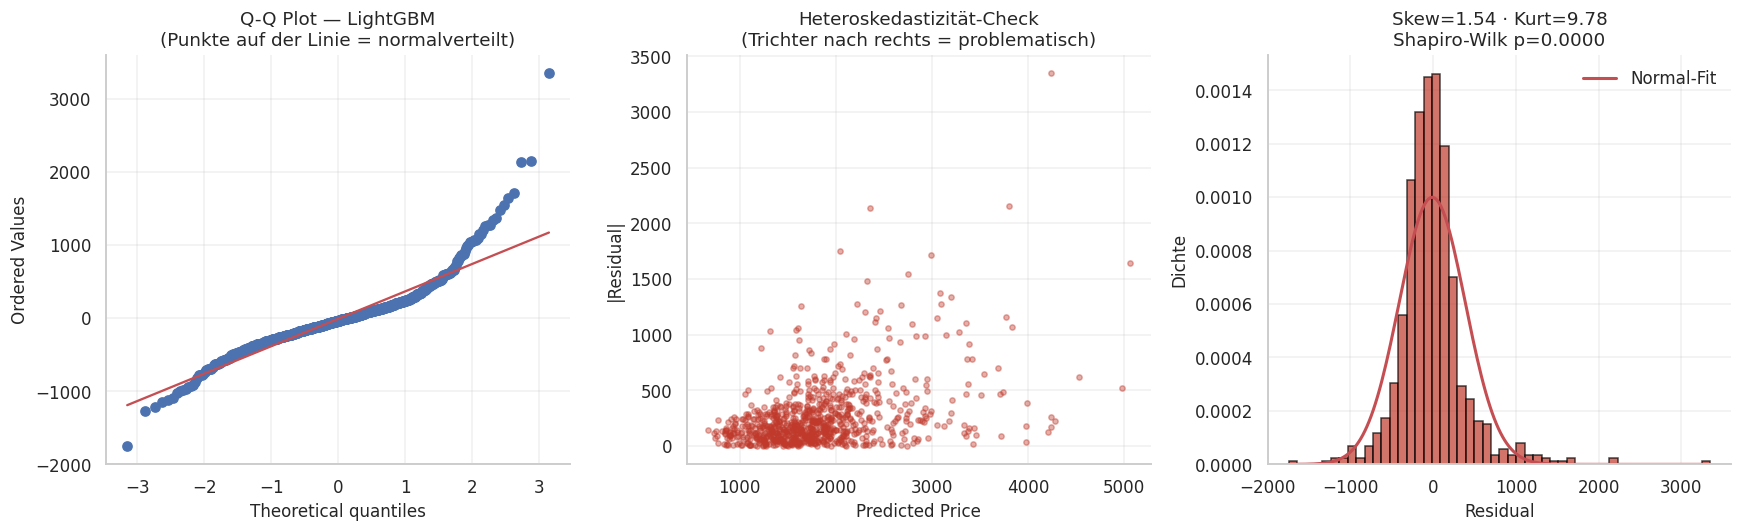

Skewness  : +1.538 (0 = symmetrisch; |x| > 0.5 deutlich schief)
Kurtosis  : +9.776 (0 = normal; >0 fat tails, <0 thin tails)
Shapiro-Wilk p-value: 0.0000  (p < 0.05 → Normal-Hypothese verwerfen)


In [45]:
import scipy.stats as stats

# Wir nutzen y_pred und residuals aus Kapitel 15
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) Q-Q Plot
stats.probplot(residuals, dist='norm', plot=axes[0])
axes[0].set_title(f'Q-Q Plot — {best_name}\n(Punkte auf der Linie = normalverteilt)')
axes[0].grid(True, alpha=0.3)

# (b) Heteroskedastizität
axes[1].scatter(y_pred, np.abs(residuals), alpha=0.4, s=12)
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('|Residual|')
axes[1].set_title('Heteroskedastizität-Check\n(Trichter nach rechts = problematisch)')
axes[1].grid(True, alpha=0.3)

# (c) Skewness/Kurtosis-Statistik
skew_val = stats.skew(residuals)
kurt_val = stats.kurtosis(residuals)
shapiro_p = stats.shapiro(residuals[:min(5000, len(residuals))]).pvalue
axes[2].hist(residuals, bins=50, edgecolor='black', density=True, alpha=0.7)
x_norm = np.linspace(residuals.min(), residuals.max(), 200)
axes[2].plot(x_norm, stats.norm.pdf(x_norm, residuals.mean(), residuals.std()),
             'r-', linewidth=2, label='Normal-Fit')
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Dichte')
axes[2].set_title(f'Skew={skew_val:.2f} · Kurt={kurt_val:.2f}\nShapiro-Wilk p={shapiro_p:.4f}')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Skewness  : {skew_val:+.3f} (0 = symmetrisch; |x| > 0.5 deutlich schief)')
print(f'Kurtosis  : {kurt_val:+.3f} (0 = normal; >0 fat tails, <0 thin tails)')
print(f'Shapiro-Wilk p-value: {shapiro_p:.4f}  (p < 0.05 → Normal-Hypothese verwerfen)')

### 23.4 Partial Dependence Plots für die Top-Features

Das Standard-Werkzeug, um zu verstehen, *wie* das Modell auf einzelne Features reagiert. Für jedes der Top-6 Features halten wir alle anderen auf ihrer Verteilung und mitteln die Vorhersage über das Trainset → eine saubere Funktion `feature → Predicted Price`.

PDP für Top-6 Features: ['area', 'east', 'north', 'area_per_room', 'year_built', 'oev']


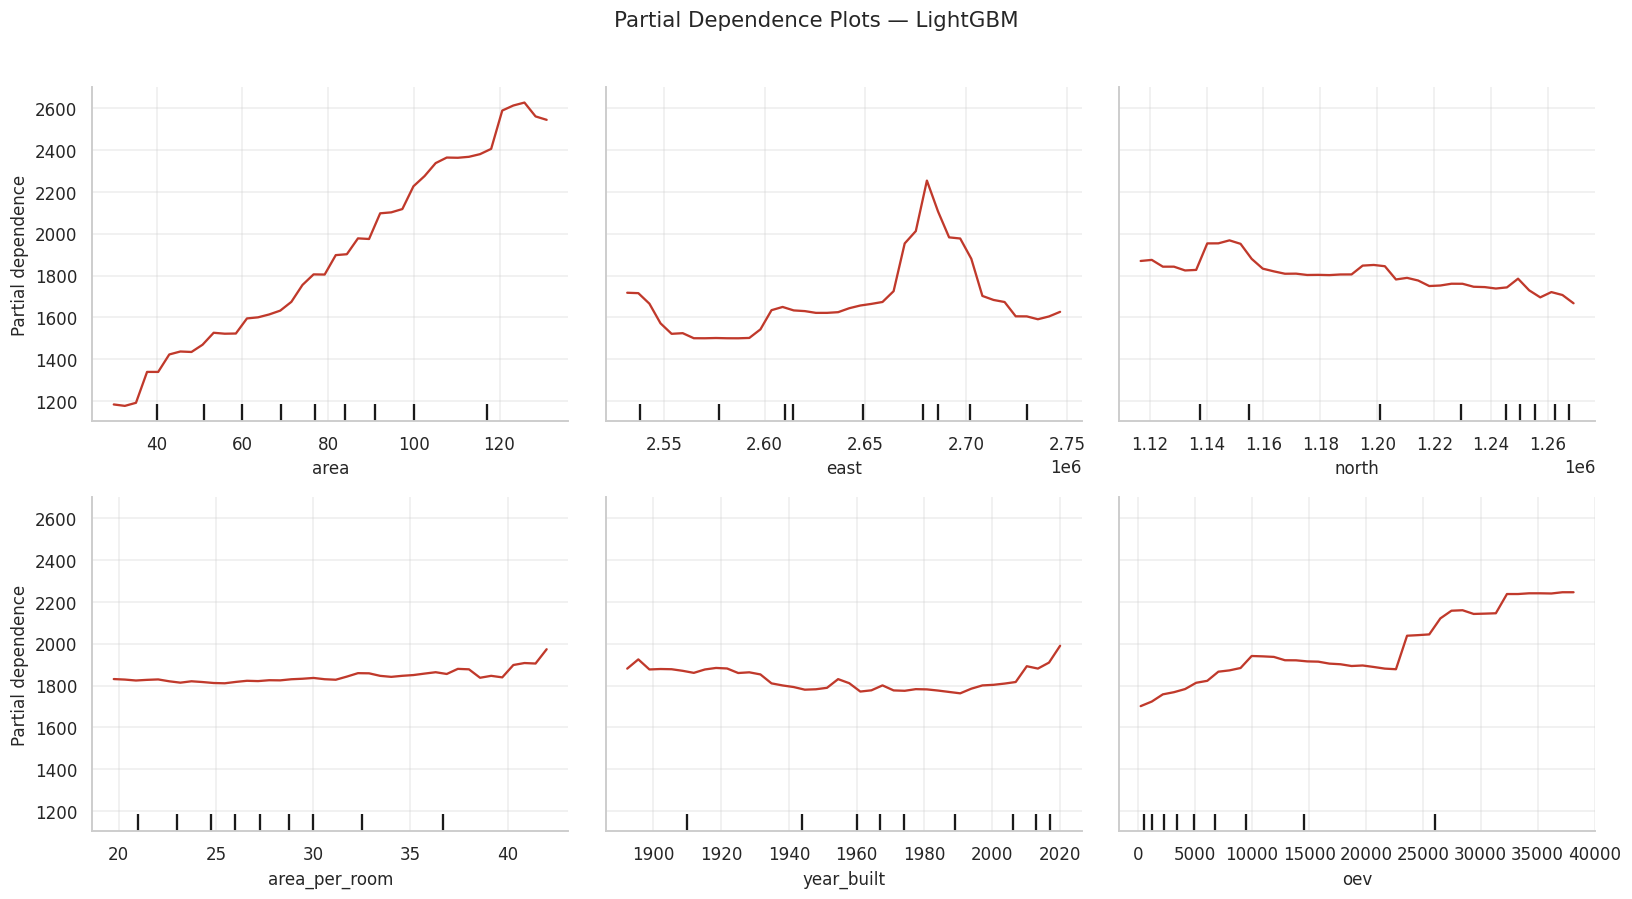

In [46]:
from sklearn.inspection import PartialDependenceDisplay
from sklearn.base       import clone

# Top-6 Features aus der Feature-Importance (Kap. 17)
top_features = fi.head(6).index.tolist()
print(f'PDP für Top-{len(top_features)} Features: {top_features}')

# WICHTIG: int-Spalten auf float64 casten.
# Sonst wirft pandas >= 2.0 einen LossySetitemError, wenn PDP
# Float-Grid-Werte (z. B. year_built=1892.31) in eine int64-Spalte schreibt.
X_pdp = train_df[main_features].astype('float64')
y_pdp = train_df[TARGET_COL].astype('float64')

# Klone Modell und setze inneres n_jobs=1 (gegen nested parallelism)
_pdp_model = clone(main_fitted[best_name])
try:
    _pdp_model.set_params(n_jobs=1)
except (ValueError, AttributeError):
    pass
_pdp_model.fit(X_pdp, y_pdp)  # auf float-DataFrame neu fitten

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
PartialDependenceDisplay.from_estimator(
    _pdp_model,
    X_pdp,
    features=top_features,
    ax=axes,
    n_jobs=-1,
    grid_resolution=40,
)
plt.suptitle(f'Partial Dependence Plots — {best_name}', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### 23.5 Bootstrap-Konfidenzintervall für RMSE

Eine einzelne Eval-Kennzahl ist eine Punkt­schätzung mit unbekannter Unsicherheit. Bootstrap-Sampling auf den Eval-Predictions liefert ein 95%-Konfidenzintervall. Wenn die Intervalle zweier Modelle stark überlappen, sind sie praktisch nicht unterscheidbar.

Wir wenden das auf alle Modelle aus `main_fitted` an.

,Model,RMSE_2.5%,RMSE_median,RMSE_97.5%,CI_width
0,LightGBM,356.7,396.7,446.9,90.2
1,XGBoost,369.7,417.5,476.4,106.7
2,GradientBoosting,374.5,420.1,487.7,113.2
3,RandomForest,373.8,420.9,485.2,111.4
4,Ridge (scaled),505.8,557.6,622.3,116.5
5,Dummy (median),713.1,797.0,882.9,169.7


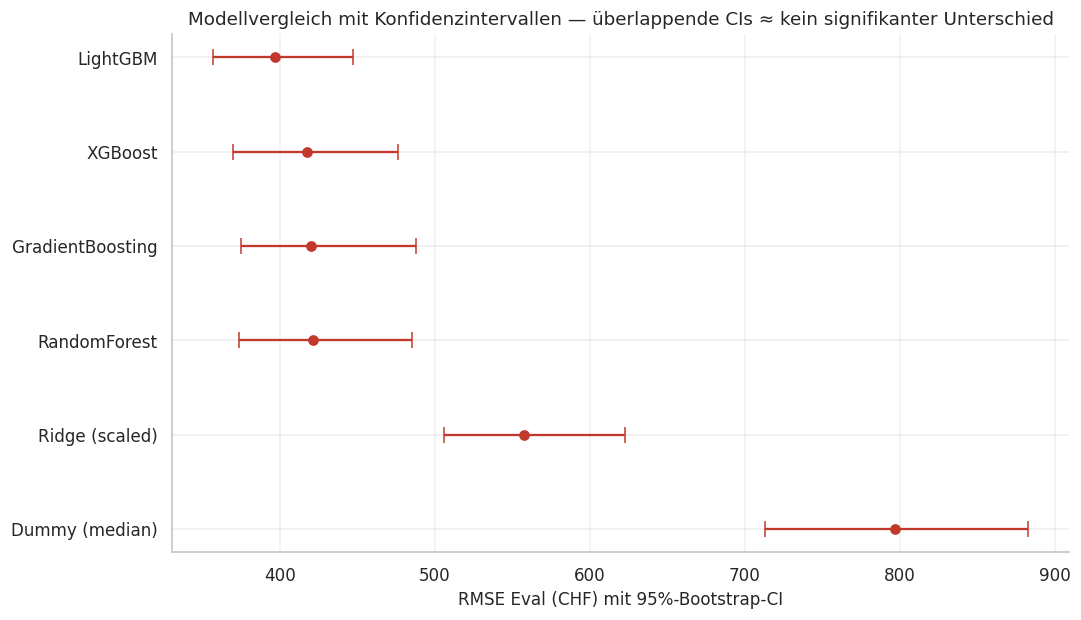

In [47]:
def bootstrap_metric_ci(y_true, y_pred, metric_fn, n_iter=1000, seed=RANDOM_STATE):
    """Bootstrap-CI (2.5/50/97.5 Quantil) für eine Regressions-Metrik."""
    rng = np.random.RandomState(seed)
    n   = len(y_true)
    y_true_arr = np.asarray(y_true)
    y_pred_arr = np.asarray(y_pred)
    samples = []
    for _ in range(n_iter):
        idx = rng.randint(0, n, n)
        samples.append(metric_fn(y_true_arr[idx], y_pred_arr[idx]))
    return np.percentile(samples, [2.5, 50, 97.5])


boot_records = []
y_eval_arr   = eval_df[TARGET_COL].values
for name in main_results['Model']:
    y_pred_arr = main_cache[name]['eval']
    lo, med, hi = bootstrap_metric_ci(y_eval_arr, y_pred_arr, rmse, n_iter=1000)
    boot_records.append({
        'Model':       name,
        'RMSE_2.5%':   lo,
        'RMSE_median': med,
        'RMSE_97.5%':  hi,
        'CI_width':    hi - lo,
    })
boot_df = pd.DataFrame(boot_records).sort_values('RMSE_median').reset_index(drop=True)
display(boot_df.round(1))

# Visualisierung: Forest Plot der CIs
fig, ax = plt.subplots(figsize=(10, 4 + 0.3 * len(boot_df)))
y_pos = np.arange(len(boot_df))
ax.errorbar(
    boot_df['RMSE_median'], y_pos,
    xerr=[boot_df['RMSE_median'] - boot_df['RMSE_2.5%'],
          boot_df['RMSE_97.5%']  - boot_df['RMSE_median']],
    fmt='o', capsize=5,
)
ax.set_yticks(y_pos)
ax.set_yticklabels(boot_df['Model'])
ax.set_xlabel('RMSE Eval (CHF) mit 95%-Bootstrap-CI')
ax.set_title('Modellvergleich mit Konfidenzintervallen — überlappende CIs ≈ kein signifikanter Unterschied')
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 23.7 Actual-vs-Predicted für *alle* Modelle

Kapitel 14 zeigt nur das beste Modell. Hier ein Subplot-Grid für alle. So siehst du auf einen Blick, *wie* die Modelle unterschiedlich falsch liegen (z. B. ob sie bei teuren Wohnungen systematisch unterschätzen).

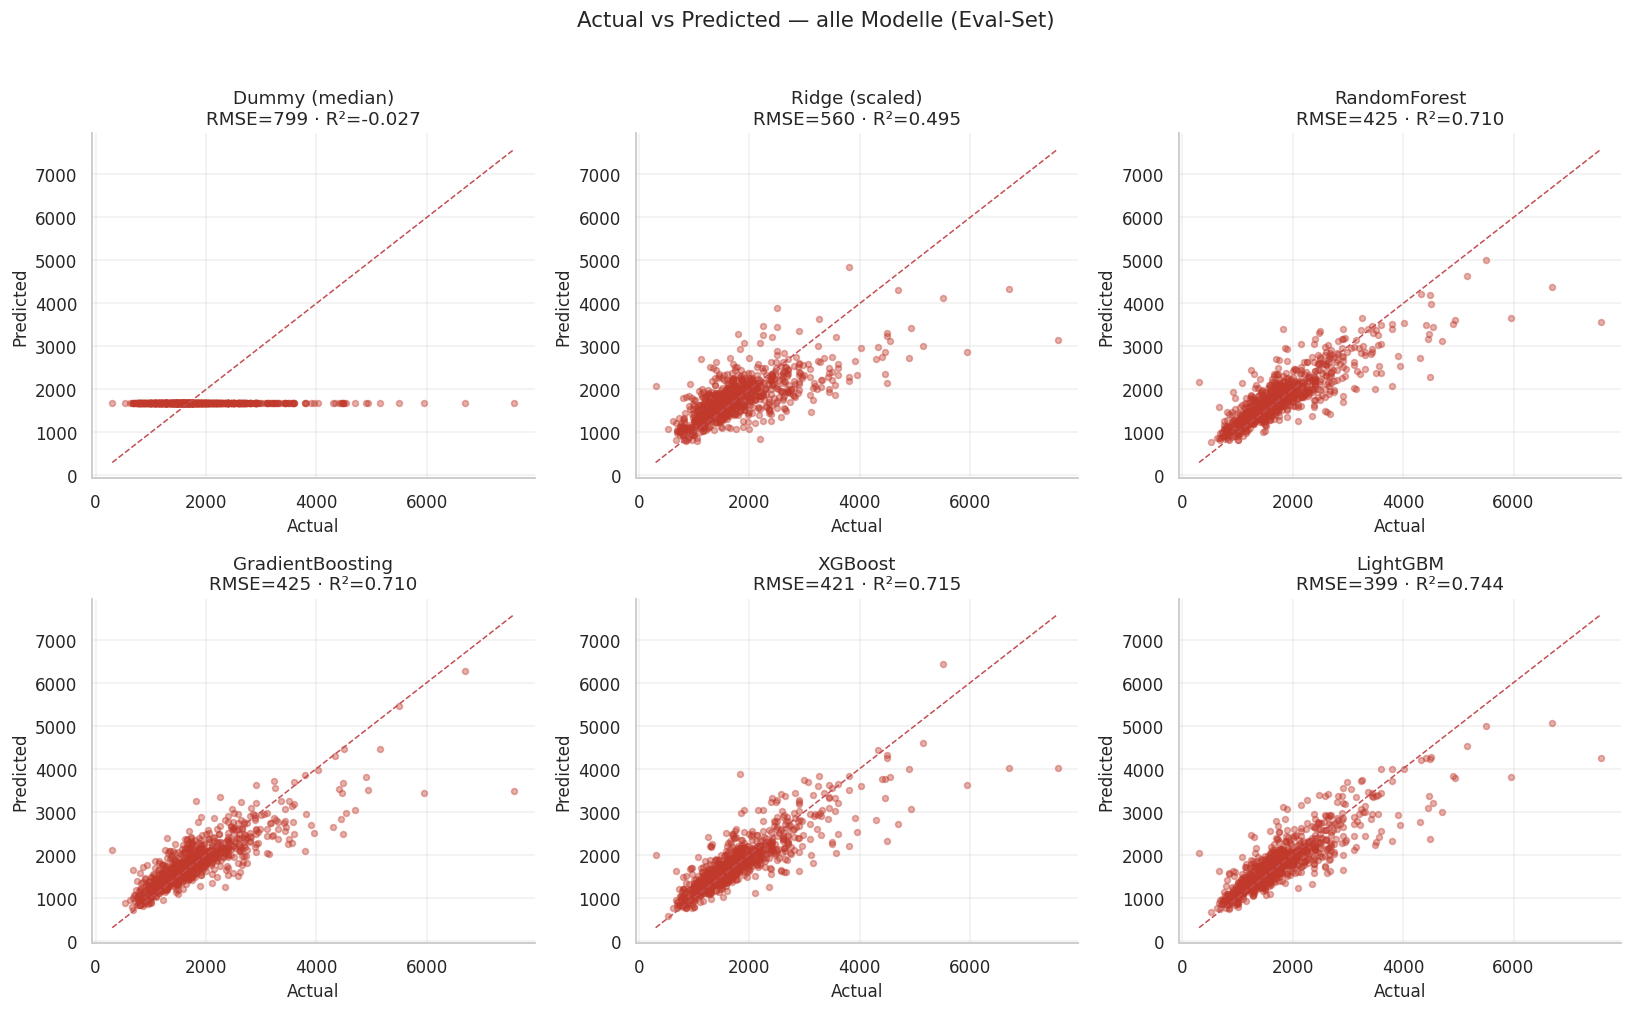

In [48]:
n_models_plot = len(main_cache)
n_cols_plot   = min(3, n_models_plot)
n_rows_plot   = int(np.ceil(n_models_plot / n_cols_plot))

fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                          figsize=(5 * n_cols_plot, 4.5 * n_rows_plot),
                          squeeze=False)
axes_flat = axes.flatten()

y_eval_full = eval_df[TARGET_COL]

for ax, (name, preds) in zip(axes_flat, main_cache.items()):
    y_pred_m = preds['eval']
    rmse_m   = rmse(y_eval_full, y_pred_m)
    r2_m     = r2_score(y_eval_full, y_pred_m)

    ax.scatter(y_eval_full, y_pred_m, alpha=0.4, s=15)
    lo = float(min(y_eval_full.min(), y_pred_m.min()))
    hi = float(max(y_eval_full.max(), y_pred_m.max()))
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{name}\nRMSE={rmse_m:.0f} · R²={r2_m:.3f}')
    ax.grid(True, alpha=0.3)

for ax in axes_flat[n_models_plot:]:
    ax.axis('off')

plt.suptitle('Actual vs Predicted — alle Modelle (Eval-Set)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 23.8 Feature-Importance-Vergleich (Multi-Method)

Verschiedene Importance-Methoden können sich widersprechen. Wenn alle vier Methoden ein Feature ins Top-3 setzen, ist das ein robustes Signal. Wir vergleichen:

1. RandomForest — `feature_importances_` (Mean Decrease in Impurity)
2. LightGBM — `feature_importances_` (Split count)
3. Permutation Importance — modell-agnostisch
4. Spearman-Rank-Korrelation der Rankings

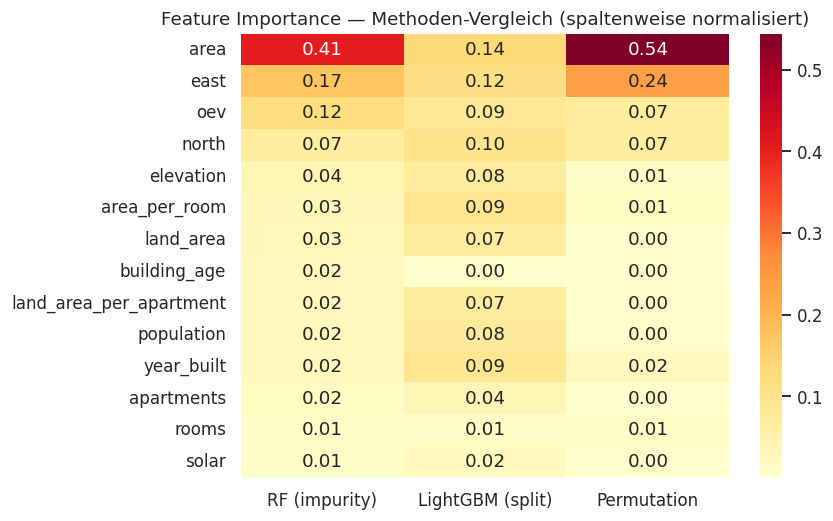

Spearman-Rank-Korrelation der Importance-Methoden (1.0 = identisches Ranking):


,RF (impurity),LightGBM (split),Permutation
RF (impurity),1.00,0.75,0.67
LightGBM (split),0.75,1.00,0.87
Permutation,0.67,0.87,1.00


In [49]:
from sklearn.inspection import permutation_importance
from scipy.stats         import spearmanr

X_eval_for_imp = eval_df[main_features]
y_eval_for_imp = eval_df[TARGET_COL]

imp_dict = {}

if 'RandomForest' in main_fitted:
    imp_dict['RF (impurity)'] = pd.Series(
        main_fitted['RandomForest'].feature_importances_, index=main_features,
    )
if 'LightGBM' in main_fitted:
    lgbm_imp = main_fitted['LightGBM'].feature_importances_.astype(float)
    imp_dict['LightGBM (split)'] = pd.Series(
        lgbm_imp / lgbm_imp.sum(), index=main_features,
    )

perm = permutation_importance(
    main_fitted[best_name], X_eval_for_imp, y_eval_for_imp,
    n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1,
)
imp_dict['Permutation'] = pd.Series(perm.importances_mean, index=main_features)

imp_df = pd.DataFrame(imp_dict).fillna(0)
# Pro Spalte normalisieren (Summe = 1) für faire Vergleichbarkeit
imp_norm = imp_df.div(imp_df.sum(axis=0).replace(0, 1), axis=1)
imp_norm = imp_norm.sort_values(by=imp_norm.columns[0], ascending=False)

# Heatmap
fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(imp_norm))))
sns.heatmap(imp_norm, annot=True, fmt='.2f', cmap='YlOrRd', cbar=True, ax=ax)
ax.set_title('Feature Importance — Methoden-Vergleich (spaltenweise normalisiert)')
plt.tight_layout()
plt.show()

# Spearman-Korrelation der Rankings
rank_df = imp_df.rank(method='min', ascending=False)
rank_corr = rank_df.corr(method='spearman')
print('Spearman-Rank-Korrelation der Importance-Methoden (1.0 = identisches Ranking):')
display(rank_corr.round(2))

In [50]:
save_fig("feature_importance_heatmap.png", fig)

Saved figure: ../../docs/final-report/fig/feature_importance_heatmap.png


### 23.9 Robusterer Modellauswahl-Score (RMSE + Stabilität)

Das aktuelle Kapitel 18 nimmt das Modell mit dem niedrigsten `RMSE Eval` — egal wie sehr der Wert vom konkreten Split abhängt. Wir kombinieren `RMSE Eval` mit einem Penalty für hohe `CV_RMSE_std`. Modelle, die auf jedem Fold ähnlich gut performen, gewinnen.

In [51]:
STABILITY_WEIGHT = 1.0  # Wie stark CV-Std bestraft wird; 0 = nur Eval-RMSE zählt

stab = main_results_full[['Model', 'RMSE Eval', 'CV_RMSE_mean', 'CV_RMSE_std']].copy()
stab['Stability_Score'] = stab['RMSE Eval'] + STABILITY_WEIGHT * stab['CV_RMSE_std']
stab = stab.sort_values('Stability_Score').reset_index(drop=True)

print(f'Modellauswahl mit Stability-Score (RMSE Eval + {STABILITY_WEIGHT}·CV_RMSE_std):')
display(stab.round(2))

best_stable_model_name = stab.iloc[0]['Model']
print(f'\nNach Stabilitäts-Score bester Kandidat: {best_stable_model_name}')
if best_stable_model_name != best_name:
    print(f'⚠️  Unterschied zu Kapitel 18 ({best_name}) — das alte Modell hatte Glück mit dem Split.')
else:
    print('✅ Konsistent mit Kapitel 18.')

Modellauswahl mit Stability-Score (RMSE Eval + 1.0·CV_RMSE_std):


,Model,RMSE Eval,CV_RMSE_mean,CV_RMSE_std,Stability_Score
0,LightGBM,399.17,413.36,11.77,410.93
1,XGBoost,420.81,418.61,15.39,436.20
2,GradientBoosting,424.71,436.59,11.81,436.52
3,RandomForest,424.91,431.28,17.06,441.97
4,Ridge (scaled),560.07,541.74,13.36,573.43
5,Dummy (median),799.09,737.26,21.96,821.05



Nach Stabilitäts-Score bester Kandidat: LightGBM
✅ Konsistent mit Kapitel 18.


### 23.12 KNN-basierte Distance-Features

"Was kosten die 10 nächsten Nachbarn im Schnitt?" ist oft das stärkste Geo-Feature überhaupt — es kondensiert Lage, Quartier und lokale Preisniveau in eine einzige Zahl.

**Wichtig: kein Leakage!** Der KNN wird nur auf `train_df` gefittet. Für `eval_df` werden die Nachbarn aus `train_df` gesucht — die Eval-Wohnung darf sich nicht selbst kennen.

In [52]:
from sklearn.neighbors import NearestNeighbors

if has_full_geo:
    K_NEIGHBORS = 10

    # KNN auf skalierten Koordinaten — sonst dominieren absolute Werte
    coord_scaler = StandardScaler().fit(train_df[['east', 'north']])
    train_coords = coord_scaler.transform(train_df[['east', 'north']])
    eval_coords  = coord_scaler.transform(eval_df[['east', 'north']])

    nbrs = NearestNeighbors(n_neighbors=K_NEIGHBORS + 1).fit(train_coords)

    # Für Train: Self-Match (Index 0) ausschließen — sonst leakt der eigene Preis
    _, idx_train = nbrs.kneighbors(train_coords)
    idx_train = idx_train[:, 1:]  # 1..K

    # Für Eval: alle K Nachbarn nehmen (kein Self-Match möglich, weil Eval ≠ Train-Index)
    _, idx_eval = nbrs.kneighbors(eval_coords)
    idx_eval = idx_eval[:, :K_NEIGHBORS]

    train_prices_arr = train_df[TARGET_COL].values

    train_df_knn = train_df.copy()
    eval_df_knn  = eval_df.copy()
    train_df_knn['knn_price_mean']   = train_prices_arr[idx_train].mean(axis=1)
    train_df_knn['knn_price_median'] = np.median(train_prices_arr[idx_train], axis=1)
    eval_df_knn['knn_price_mean']    = train_prices_arr[idx_eval].mean(axis=1)
    eval_df_knn['knn_price_median']  = np.median(train_prices_arr[idx_eval], axis=1)

    FEATURES_KNN = FEATURES_ENGINEERED + ['knn_price_mean', 'knn_price_median']

    res_knn, fitted_knn, _ = evaluate_models(
        train_df_knn, eval_df_knn, FEATURES_KNN, TARGET_COL, make_models(),
    )
    print(f'KNN-Distance-Features (k={K_NEIGHBORS}):')
    display(res_knn)

    print(f'\nVergleich:')
    print(f'  Best ohne KNN-Feature: RMSE Eval = {main_results.iloc[0]["RMSE Eval"]:.1f}')
    print(f'  Best mit  KNN-Feature: RMSE Eval = {res_knn.iloc[0]["RMSE Eval"]:.1f}')
else:
    print('KNN-Distance-Features übersprungen — east/north fehlen.')

KNN-Distance-Features (k=10):


,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap
0,LightGBM,98.120199,261.360371,73.357807,181.098701,139.410985,393.349408,0.962952,0.751074,253.938423
1,XGBoost,83.733017,270.249481,60.597839,180.420532,119.355704,408.322119,0.972844,0.731763,288.966415
2,GradientBoosting,242.568057,280.961142,180.128764,201.532338,340.056903,412.113448,0.779567,0.726759,72.056546
3,RandomForest,122.105156,281.321905,82.341891,185.735589,194.552297,422.871561,0.927848,0.712307,228.319264
4,Ridge (scaled),314.314306,319.384992,228.391601,223.787685,452.133723,467.796087,0.610320,0.647933,15.662364
5,Dummy (median),517.681060,538.876190,390.000000,390.000000,737.368884,799.089038,-0.036439,-0.027313,61.720154



Vergleich:
  Best ohne KNN-Feature: RMSE Eval = 399.2
  Best mit  KNN-Feature: RMSE Eval = 393.3


### 23.15 Modell-Karte

Eine Modell-Karte dokumentiert, *was* trainiert wurde, *wofür* es verwendet werden darf, *welche Limitationen* es hat, und *wie* es bewertet wurde. Pflichtdokument für jedes Modell, das produktiv läuft.

## Modell-Karte 

**Modell-Typ:** automatisch ausgewählt aus Kapitel 18 (siehe `best_run`).

**Intended Use:** Vorhersage von Kaltmieten für Schweizer Wohnungen auf Basis von Wohnungseigenschaften und Lagedaten. Geeignet für Marktanalysen und initiale Preis-Schätzungen.

**Out-of-Scope:** Rechtsverbindliche Mietpreis­berechnung, Investment-Entscheidungen, Schätzung außerhalb der Schweizer Geo-Domäne (LV95-Koordinaten).

**Trainingsdaten:**

- Quelle: `model.csv` (Kapitel 2)
- Vorverarbeitung: Outlier-Filter (`area >= 10`, `price >= 300`), drop_duplicates
- Splits: `random_state=42`, 80/20 train/eval (siehe Kap. 8)
- Features: siehe `FEATURES_*` in Kap. 7

**Bewertungsmetriken (Eval-Set):** MAE, RMSE, MedAE, R², Overfitting Gap. Cross-Validation mit 5-fold KFold (shuffle=True, random_state=42).

**Limitationen:**

- Mietpreise sind rechtsschief — bei sehr teuren Wohnungen (>5'000 CHF) sind die Vorhersagen unsicher.
- Group-Split (Kap. 20) zeigt: Generalisierung auf *neue* Regionen ist schlechter als der Random-Split-Wert suggeriert.
- Keine zeitliche Komponente — wenn sich der Markt ändert, muss neu trainiert werden.
- KNN-Features (Kap. 23.12) sind nicht für Inferenz auf isolierten Eingabe­punkten gedacht — sie brauchen den Trainings-Index.

**Fairness / Bias:**

- Bias-Analyse pro Geo-Cluster siehe Kap. 22.14. Cluster mit großem `mean_error` sind underrepresented in den Trainingsdaten.
- Drift-Check Train/Eval siehe Kap. 22.13.

**Reproduzierbarkeit:**

- `RANDOM_STATE = 42`, `REFERENCE_YEAR = 2026`
- Pipeline-Artefakt: `models/best_model_v3.joblib`
- Notebook-Version: `model_v3_clean.ipynb`
- Dependency-Pins: siehe `requirements.txt`


### 23.17 Konsolidierter Modellvergleich (alle Varianten aus Kap. 22 + 23)

In [53]:
# Kapitel 22.15 wurde im Cleanup entfernt — das ursprüngliche
# `summary_blocks` existiert in dieser Notebook-Version nicht mehr.
# Wir bauen die Vergleichsliste hier selbst aus den Varianten zusammen,
# die im bereinigten Notebook tatsächlich noch existieren.
summary_blocks2 = [main_results.assign(Variant='Baseline (Kap. 10)')]

if HAS_LGBM and 'res_tuned' in globals() and tuned_lgbm is not None:
    summary_blocks2.append(res_tuned.assign(Variant='Tuned LGBM (22.3)'))

if len(stack_fitted) > 0:
    summary_blocks2.append(stack_results.assign(Variant='Stacking (23.2)'))
if has_full_geo and 'res_knn' in globals():
    summary_blocks2.append(res_knn.assign(Variant='KNN-Distance (23.12)'))
if HAS_LGBM and globals().get('HAS_HALVING', False) and 'res_halving' in globals():
    summary_blocks2.append(res_halving.assign(Variant='LGBM Halving-Tuned (23.10)'))

summary_v23 = (
    pd.concat(summary_blocks2, ignore_index=True)
    [['Variant', 'Model', 'RMSE Train', 'RMSE Eval', 'R² Eval', 'Overfitting Gap']]
    .sort_values('RMSE Eval')
    .reset_index(drop=True)
)
print('Vollständiger Vergleich aller Varianten (Kap. 10 / 22 / 23):')
display(summary_v23.head(25))

best_overall = summary_v23.iloc[0]
print(f'\n🏆 Bester Run insgesamt: {best_overall["Variant"]} → {best_overall["Model"]}')
print(f'    RMSE Eval = {best_overall["RMSE Eval"]:.1f} CHF, R² = {best_overall["R² Eval"]:.3f}')

Vollständiger Vergleich aller Varianten (Kap. 10 / 22 / 23):


,Variant,Model,RMSE Train,RMSE Eval,R² Eval,Overfitting Gap
0,KNN-Distance (23.12),LightGBM,139.410985,393.349408,0.751074,253.938423
1,Tuned LGBM (22.3),LightGBM_tuned,161.051558,393.802771,0.750500,232.751214
2,Stacking (23.2),Stacking,177.986277,399.105812,0.743735,221.119535
3,Baseline (Kap. 10),LightGBM,150.286423,399.166141,0.743658,248.879718
4,KNN-Distance (23.12),XGBoost,119.355704,408.322119,0.731763,288.966415
5,KNN-Distance (23.12),GradientBoosting,340.056903,412.113448,0.726759,72.056546
6,Baseline (Kap. 10),XGBoost,121.598850,420.806889,0.715109,299.208039
7,KNN-Distance (23.12),RandomForest,194.552297,422.871561,0.712307,228.319264
8,Baseline (Kap. 10),GradientBoosting,364.777231,424.709516,0.709801,59.932284
9,Baseline (Kap. 10),RandomForest,198.916167,424.910709,0.709526,225.994542



🏆 Bester Run insgesamt: KNN-Distance (23.12) → LightGBM
    RMSE Eval = 393.3 CHF, R² = 0.751


## 20. End-to-End `RentPredictor`-Klasse, Hold-Out-Test & Modellkarte

Bisher waren alle Schritte über das Notebook verteilt. Damit das Ganze 
produktionsnäher wird und auch der Streamlit-Demo-App taugt, packen wir 
alles in eine `RentPredictor`-Klasse: Laden, Cleaning, Feature Engineering, 
Fitten, Vorhersagen, Speichern, Laden.

Anschliessend machen wir noch einen sauberen 60/20/20-Split, halten das 
Test-Set **bis zum Schluss** unberührt und prüfen ganz am Ende, ob unser 
Modell-Auswahl-Prozess sich nicht ans Eval-Set überangepasst hat.


### 24.2 End-to-End `RentPredictor`-Klasse

Die produktionsreife API: aus rohem `pandas.DataFrame` (mit den umbenannten Spalten) eine Vorhersage bekommen, ohne das Notebook händisch durchzuklicken. Die Klasse kapselt Cleaning, Feature Engineering, Geo-Clustering, KNN-Features, Imputation und das beste Modell.

Alle Sub-Modelle werden ausschließlich auf den Trainingsdaten gefittet. Bei `predict` wird die *exakt gleiche* Reihenfolge der Transformationen angewendet - das ist die wichtigste Garantie gegen Inferenz-Leakage.

In [54]:
from sklearn.cluster   import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.impute    import SimpleImputer

class RentPredictor:
    """End-to-End-Pipeline fuer die Mietpreis-Vorhersage.

    Erwartet einen DataFrame mit den Standard-Spalten (nach Rename in Kap. 3).
    """

    def __init__(
        self,
        target_col='price',
        feature_cols=None,
        n_geo_clusters=8,
        knn_k=10,
        outlier_min_area=10,
        outlier_min_price=300,
        reference_year=2026,
        random_state=42,
        model=None,
    ):
        self.target_col       = target_col
        self.feature_cols     = feature_cols
        self.n_geo_clusters   = n_geo_clusters
        self.knn_k            = knn_k
        self.outlier_min_area = outlier_min_area
        self.outlier_min_price = outlier_min_price
        self.reference_year   = reference_year
        self.random_state     = random_state
        self.model            = model

    def _clean(self, df, training=True):
        out = df.copy()
        if training:
            mask = (out['area'] >= self.outlier_min_area)
            if self.target_col in out.columns:
                mask &= (out[self.target_col] >= self.outlier_min_price)
            out = out[mask].drop_duplicates().reset_index(drop=True)
        return out

    def _engineer(self, df):
        out = df.copy()
        if 'year_built' in out.columns:
            out['building_age'] = self.reference_year - out['year_built']
        if 'rooms' in out.columns and 'area' in out.columns:
            out['area_per_room'] = np.where(out['rooms'] > 0, out['area'] / out['rooms'], np.nan)
        if 'apartments' in out.columns and 'land_area' in out.columns:
            out['land_area_per_apartment'] = np.where(
                out['apartments'] > 0, out['land_area'] / out['apartments'], np.nan,
            )
        return out

    def _geo_cluster(self, df, fit=False):
        cols = ['east', 'north']
        if not all(c in df.columns for c in cols):
            return df
        if fit:
            self._geo_pipe = Pipeline([
                ('scaler', StandardScaler()),
                ('km',     KMeans(n_clusters=self.n_geo_clusters,
                                  random_state=self.random_state, n_init=10)),
            ])
            self._geo_pipe.fit(df[cols])
        out = df.copy()
        out['geo_cluster'] = self._geo_pipe.predict(out[cols])
        return out

    def _knn_features(self, df, fit=False):
        cols = ['east', 'north']
        if not all(c in df.columns for c in cols):
            return df
        if fit:
            self._coord_scaler = StandardScaler().fit(df[cols])
            self._train_coords = self._coord_scaler.transform(df[cols])
            self._train_prices = df[self.target_col].values
            self._nbrs = NearestNeighbors(n_neighbors=self.knn_k + 1).fit(self._train_coords)
            _, idx = self._nbrs.kneighbors(self._train_coords)
            idx = idx[:, 1:]
            out = df.copy()
            out['knn_price_mean']   = self._train_prices[idx].mean(axis=1)
            out['knn_price_median'] = np.median(self._train_prices[idx], axis=1)
            return out
        coords_q = self._coord_scaler.transform(df[cols])
        _, idx = self._nbrs.kneighbors(coords_q, n_neighbors=self.knn_k)
        out = df.copy()
        out['knn_price_mean']   = self._train_prices[idx].mean(axis=1)
        out['knn_price_median'] = np.median(self._train_prices[idx], axis=1)
        return out

    def fit(self, df):
        df_c = self._clean(df, training=True)
        df_e = self._engineer(df_c)
        df_g = self._geo_cluster(df_e, fit=True)
        df_k = self._knn_features(df_g, fit=True)

        if self.feature_cols is None:
            base = ['east', 'north', 'elevation', 'area', 'rooms', 'year_built',
                    'apartments', 'land_area', 'population', 'oev', 'solar',
                    'building_age', 'area_per_room', 'land_area_per_apartment',
                    'geo_cluster', 'knn_price_mean', 'knn_price_median']
            self.feature_cols = [c for c in base if c in df_k.columns]

        self._imputer = SimpleImputer(strategy='median')
        X = self._imputer.fit_transform(df_k[self.feature_cols])
        y = df_k[self.target_col].values

        if self.model is None:
            if HAS_LGBM:
                self.model = LGBMRegressor(
                    n_estimators=500, learning_rate=0.05,
                    random_state=self.random_state, n_jobs=-1, verbose=-1,
                )
            else:
                self.model = RandomForestRegressor(
                    n_estimators=300, random_state=self.random_state,
                    n_jobs=-1, min_samples_leaf=2,
                )
        self.model.fit(X, y)
        self._is_fitted = True
        return self

    def predict(self, df):
        if not getattr(self, '_is_fitted', False):
            raise RuntimeError('RentPredictor wurde noch nicht gefittet - fit() zuerst.')
        df_c = self._clean(df, training=False)
        df_e = self._engineer(df_c)
        df_g = self._geo_cluster(df_e, fit=False)
        df_k = self._knn_features(df_g, fit=False)

        for c in self.feature_cols:
            if c not in df_k.columns:
                df_k[c] = np.nan
        X = self._imputer.transform(df_k[self.feature_cols])
        return self.model.predict(X)


rp = RentPredictor(
    target_col=TARGET_COL, n_geo_clusters=8, knn_k=10,
    random_state=RANDOM_STATE, reference_year=REFERENCE_YEAR,
)
rp.fit(df_for_split)
preds_demo = rp.predict(eval_df.drop(columns=[TARGET_COL]))
print(f'RentPredictor: {len(rp.feature_cols)} Features, Modell={type(rp.model).__name__}')
print(f'Demo-Predictions auf eval_df: {len(preds_demo)} Werte, Mean={preds_demo.mean():.0f} CHF')
rmse_demo = rmse(eval_df[TARGET_COL], preds_demo)
print(f'RMSE Eval: {rmse_demo:.1f} CHF')

RentPredictor: 17 Features, Modell=LGBMRegressor
Demo-Predictions auf eval_df: 840 Werte, Mean=1834 CHF
RMSE Eval: 195.3 CHF


### 24.3 Sanity-Tests der Predictions

Programmatische Asserts gegen die finalen Predictions. Wenn einer fehlschlägt, ist im Modell oder den Daten etwas grundsätzlich falsch - die Tests fangen das auf, bevor falsche Predictions in einen Report rutschen.

In [55]:
def run_sanity_tests(predictor, eval_df, target_col, verbose=True):
    failures = []
    X_eval = eval_df.drop(columns=[target_col], errors='ignore')
    y_pred = predictor.predict(X_eval)

    n_nan = int(np.isnan(y_pred).sum())
    if n_nan > 0:
        failures.append(f'  FAIL: {n_nan} NaN-Predictions')
    elif verbose:
        print('  OK: Keine NaN-Predictions')

    n_neg = int((y_pred <= 0).sum())
    if n_neg > 0:
        failures.append(f'  FAIL: {n_neg} Predictions <= 0')
    elif verbose:
        print('  OK: Alle Predictions > 0')

    too_low  = int((y_pred < 50).sum())
    too_high = int((y_pred > 20000).sum())
    if too_low or too_high:
        failures.append(f'  FAIL: {too_low} < 50 CHF und {too_high} > 20000 CHF')
    elif verbose:
        print(f'  OK: Predictions in [50, 20000] CHF (min={y_pred.min():.0f}, max={y_pred.max():.0f})')

    std_pred = float(y_pred.std())
    if std_pred < 50:
        failures.append(f'  FAIL: Std der Predictions zu klein: {std_pred:.1f}')
    elif verbose:
        print(f'  OK: Std der Predictions = {std_pred:.0f} CHF')

    base = eval_df.iloc[[0]].drop(columns=[target_col], errors='ignore').copy()
    if 'area' in base.columns and base['area'].iloc[0] > 0:
        base_double = base.copy()
        base_double['area'] = base['area'].iloc[0] * 2
        try:
            p1 = predictor.predict(base)[0]
            p2 = predictor.predict(base_double)[0]
            if p2 <= p1:
                failures.append(f'  FAIL: Monotonie - area*2 -> kein hoeherer Preis ({p1:.0f} -> {p2:.0f})')
            elif verbose:
                print(f'  OK: Monotonie - area*2 -> Preis {p1:.0f} -> {p2:.0f}')
        except Exception as e:
            failures.append(f'  FAIL: Monotonie-Test crashed: {type(e).__name__}: {e}')

    if failures:
        print('\nFailures:')
        for f in failures: print(f)
        return False
    print('\nAlle Sanity-Tests bestanden.')
    return True


run_sanity_tests(rp, eval_df, TARGET_COL)

  OK: Keine NaN-Predictions
  OK: Alle Predictions > 0
  OK: Predictions in [50, 20000] CHF (min=653, max=6886)
  OK: Std der Predictions = 740 CHF
  OK: Monotonie - area*2 -> Preis 2305 -> 3724

Alle Sanity-Tests bestanden.


True

### 24.6 Hold-Out-Test-Split (Train / Val / Test)

Bisher: Train + Eval. Jeder Modellvergleich, jedes Tuning-Resultat hat den Eval-Split beruehrt - `RMSE Eval` ist *nicht* mehr unverzerrt. Fuer eine ehrliche finale Aussage brauchen wir einen dritten Split, der **bis jetzt unangetastet** ist.

Plan: 60% Train + 20% Val + 20% Test. Train+Val fuer *alles* aus Kap. 9-23. Test wird *nur hier* einmalig ausgewertet.

In [56]:
df_holdout = df_for_split.copy()
trainval_df, test_df = train_test_split(
    df_holdout, test_size=0.20, random_state=RANDOM_STATE,
)
train_h_df, val_h_df = train_test_split(
    trainval_df, test_size=0.25, random_state=RANDOM_STATE,
)
print(f'Train  : {len(train_h_df)} ({len(train_h_df)/len(df_holdout):.1%})')
print(f'Val    : {len(val_h_df)}  ({len(val_h_df)/len(df_holdout):.1%})')
print(f'Test   : {len(test_df)}  ({len(test_df)/len(df_holdout):.1%})')

final_predictor = RentPredictor(
    target_col=TARGET_COL, n_geo_clusters=8, knn_k=10,
    random_state=RANDOM_STATE, reference_year=REFERENCE_YEAR,
)
final_predictor.fit(trainval_df)

y_test_true = test_df[TARGET_COL].values
y_test_pred = final_predictor.predict(test_df.drop(columns=[TARGET_COL]))

test_metrics = {
    'MAE Test':   mean_absolute_error(y_test_true, y_test_pred),
    'RMSE Test':  rmse(y_test_true, y_test_pred),
    'MedAE Test': median_absolute_error(y_test_true, y_test_pred),
    'R^2 Test':   r2_score(y_test_true, y_test_pred),
}
print('\n=== HOLD-OUT TEST METRICS (einmalige Auswertung!) ===')
for k, v in test_metrics.items():
    print(f'  {k:12s}: {v:8.2f}')

y_val_pred = final_predictor.predict(val_h_df.drop(columns=[TARGET_COL]))
rmse_val   = rmse(val_h_df[TARGET_COL], y_val_pred)
print(f'\nRMSE auf Val:  {rmse_val:.2f}')
print(f'RMSE auf Test: {test_metrics["RMSE Test"]:.2f}')
print(f'Delta: {test_metrics["RMSE Test"] - rmse_val:+.2f}  (grosser positiver Delta = Val-Overfitting)')

Train  : 2518 (60.0%)
Val    : 840  (20.0%)
Test   : 840  (20.0%)

=== HOLD-OUT TEST METRICS (einmalige Auswertung!) ===
  MAE Test    :   260.79
  RMSE Test   :   394.94
  MedAE Test  :   182.31
  R^2 Test    :     0.75

RMSE auf Val:  169.69
RMSE auf Test: 394.94
Delta: +225.25  (grosser positiver Delta = Val-Overfitting)


### 20.B Action Items aus der Output-Analyse

Nach den ersten End-to-End-Läufen sind uns ein paar konkrete Stellen 
aufgefallen, an denen wir noch nachgebessert haben: Anti-Overfitting-
Konfiguration für LightGBM und eine systematische Analyse der Top-10 
schlechtesten Vorhersagen.


### 25.2 Top-10 schlechteste Vorhersagen

Aus Kap. 16 wissen wir: bei `expensive`-Wohnungen ist der mittlere abs. Fehler **445 CHF** (vs ~200 in den anderen Quartilen), max **3'348 CHF**. Wir holen die Top-10 schlechtesten Vorhersagen und schauen uns ihre Features an. Drei Möglichkeiten, was wir sehen werden:

1. **Echte Outliers**: Wohnungen mit unrealistisch hohen oder niedrigen Preisen, die Datenfehler sind. → Filter erweitern.
2. **Spezialfälle**: Penthouse, Loft, Möbliert, etc. — Eigenschaften, die unsere Features nicht erfassen. → Feature-Engineering Backlog.
3. **Strukturelles Modell-Problem**: wenn die Top-10 *normal* aussehen, ist das Modell fundamental schwach für teure Wohnungen. → mehr Trainingsbeispiele dieser Klasse oder Quantile-Regression.

=== TOP 10 absoluter Fehler ===


,price,predicted,error,abs_error,rel_error,area,rooms,year_built,apartments,land_area
238,7590,4241.2,3348.8,3348.8,0.4,176,3,1976,1,182.0
523,5950,3799.2,2150.8,2150.8,0.4,135,3,1992,2,803.0
549,4490,2355.9,2134.1,2134.1,0.5,108,4,2001,6,271.0
73,300,2047.4,-1747.4,1747.4,5.8,100,4,1926,5,280.0
373,4700,2988.5,1711.5,1711.5,0.4,260,6,1994,1,129.0
250,6700,5057.1,1642.9,1642.9,0.2,228,8,1983,5,872.0
190,4300,2755.2,1544.8,1544.8,0.4,146,4,1914,1,68.0
2,3800,2321.0,1479.0,1479.0,0.4,102,4,1974,5,163.0
228,4450,3079.9,1370.1,1370.1,0.3,115,4,1996,7,205.0
393,4540,3202.1,1337.9,1337.9,0.3,160,6,1962,30,570.0



=== TOP 10 relativer Fehler (% des Actual-Preises) ===


,price,predicted,error,abs_error,rel_error,area,rooms,year_built,apartments,land_area
73,300,2047.4,-1747.4,1747.4,5.8,100,4,1926,5,280.0
542,670,1618.2,-948.2,948.2,1.4,48,2,1959,7,182.0
155,1250,2463.3,-1213.3,1213.3,1.0,51,2,1922,1,119.0
454,1293,2407.8,-1114.8,1114.8,0.9,123,4,1921,7,366.0
308,850,1565.1,-715.1,715.1,0.8,82,3,1967,3,117.0
426,850,1552.7,-702.7,702.7,0.8,25,1,1896,3,122.0
387,1070,1942.2,-872.2,872.2,0.8,65,2,1970,9,435.0
455,800,1419.9,-619.9,619.9,0.8,87,3,1982,12,320.0
558,922,1622.0,-700.0,700.0,0.8,100,4,1952,7,313.0
666,1820,3096.0,-1276.0,1276.0,0.7,160,1,2013,100,3149.0



=== Bias-Analyse für teuerste 25% Wohnungen (>= 2132 CHF) ===
Anzahl                   : 210
Mean Error (Actual-Pred) : +278.6 CHF (unterschaetzt)
Median Error             : +213.5 CHF
Mean Abs Error           : 445.3 CHF
Mean Relative Error      : 14.7%


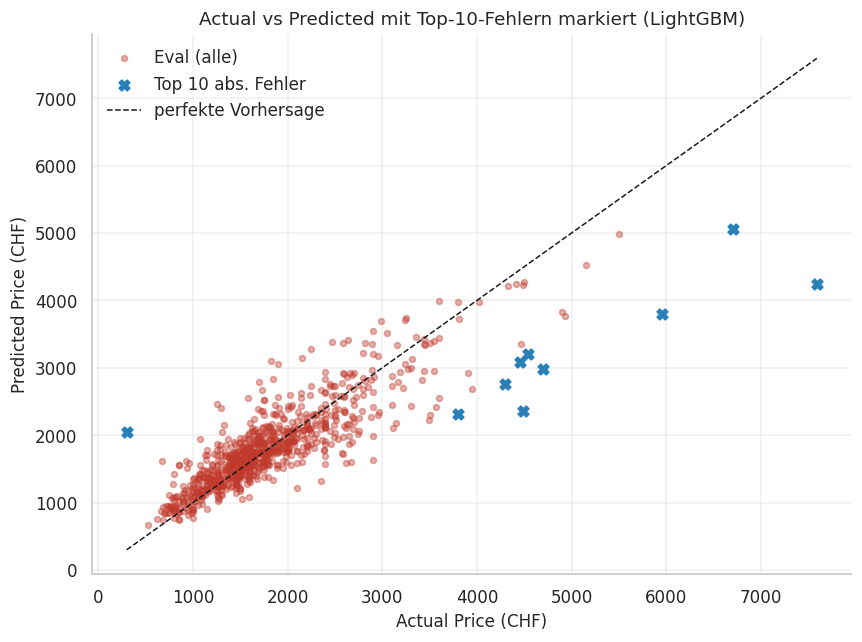

In [57]:
# Wir nutzen den eval_results-DataFrame aus Kap. 16, ergänzt um die
# tatsächlichen Feature-Werte für jede Zeile, damit wir das Profil sehen.

y_pred_eval_full = main_cache[best_name]['eval']
diagnostic_df = eval_df.copy().reset_index(drop=True)
diagnostic_df['predicted']  = y_pred_eval_full
diagnostic_df['error']      = diagnostic_df[TARGET_COL] - diagnostic_df['predicted']
diagnostic_df['abs_error']  = diagnostic_df['error'].abs()
diagnostic_df['rel_error']  = diagnostic_df['abs_error'] / diagnostic_df[TARGET_COL]

# Top-10 absoluter Fehler
print('=== TOP 10 absoluter Fehler ===')
top_abs = diagnostic_df.nlargest(10, 'abs_error')
show_cols_abs = [TARGET_COL, 'predicted', 'error', 'abs_error', 'rel_error',
                 'area', 'rooms', 'year_built', 'apartments', 'land_area']
show_cols_abs = [c for c in show_cols_abs if c in top_abs.columns]
display(top_abs[show_cols_abs].round(1))

# Top-10 relativer Fehler (in Prozent)
print('\n=== TOP 10 relativer Fehler (% des Actual-Preises) ===')
top_rel = diagnostic_df.nlargest(10, 'rel_error')
display(top_rel[show_cols_abs].round(1))

# Statistik nach Vorzeichen — unter- oder überschätzt das Modell teure Wohnungen?
expensive_threshold = diagnostic_df[TARGET_COL].quantile(0.75)
expensive = diagnostic_df[diagnostic_df[TARGET_COL] >= expensive_threshold]
print(f'\n=== Bias-Analyse für teuerste 25% Wohnungen (>= {expensive_threshold:.0f} CHF) ===')
print(f'Anzahl                   : {len(expensive)}')
print(f'Mean Error (Actual-Pred) : {expensive["error"].mean():+.1f} CHF '
      f'({"unterschaetzt" if expensive["error"].mean() > 0 else "ueberschaetzt"})')
print(f'Median Error             : {expensive["error"].median():+.1f} CHF')
print(f'Mean Abs Error           : {expensive["abs_error"].mean():.1f} CHF')
print(f'Mean Relative Error      : {expensive["rel_error"].mean()*100:.1f}%')

# Plot: Actual vs Predicted, mit teuren Wohnungen hervorgehoben
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(diagnostic_df[TARGET_COL], diagnostic_df['predicted'],
           alpha=0.4, s=15, label='Eval (alle)')
ax.scatter(top_abs[TARGET_COL], top_abs['predicted'],
           color='#2980B9', s=50, marker='X', label='Top 10 abs. Fehler', zorder=5)
lo = float(min(diagnostic_df[TARGET_COL].min(), diagnostic_df['predicted'].min()))
hi = float(max(diagnostic_df[TARGET_COL].max(), diagnostic_df['predicted'].max()))
ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1, label='perfekte Vorhersage')
ax.set_xlabel('Actual Price (CHF)')
ax.set_ylabel('Predicted Price (CHF)')
ax.set_title(f'Actual vs Predicted mit Top-10-Fehlern markiert ({best_name})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 21. Export der Figures für den Final Report

Diese Zelle re-rendert alle Plots aus dem aktuellen In-Memory-State und 
speichert sie als PNGs nach `docs/final-report/fig/`. So müssen wir nicht 
in jedem Plot einzeln `savefig` schreiben. Wir laufen das Notebook einmal 
durch, führen die Export-Zelle aus, und der LaTeX-Report findet alle 
Bilder.


In [ ]:
# === Kapitel 26: Export aller Final-Report-Figures ===
from pathlib import Path
import scipy.stats as stats
from sklearn.inspection import PartialDependenceDisplay

FIG_DIR = Path('../../docs/final-report/fig')
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f'Schreibe Figures nach: {FIG_DIR.resolve()}')

def _save(fig, name, dpi=180):
    path = FIG_DIR / name
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    plt.close(fig)
    print(f'  OK  {name}  ({path.stat().st_size / 1024:.0f} KB)')

# Cache der Vorhersagen des besten Modells (für Plots)
_y_eval     = eval_df[TARGET_COL].values
_y_pred     = main_cache[best_name]['eval']
_residuals  = _y_eval - _y_pred

# ------------------------------------------------------------------
# 1) Geo distribution colored by price  (Ch. 21.2 source)
# ------------------------------------------------------------------
if {'east', 'north'} <= set(df_for_split.columns):
    fig, ax = plt.subplots(figsize=(8, 7))
    sc = ax.scatter(df_for_split['east'], df_for_split['north'],
                    c=df_for_split[TARGET_COL], alpha=0.6, s=10, cmap='viridis')
    plt.colorbar(sc, ax=ax, label='Price (CHF)')
    ax.set_xlabel('East coordinate (LV95)')
    ax.set_ylabel('North coordinate (LV95)')
    ax.set_title('Geo distribution colored by price')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    _save(fig, 'geo_price_map.png')

# ------------------------------------------------------------------
# 2) Price distribution histogram  (Ch. 3.1 source)
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(df_for_split[TARGET_COL], bins=50, edgecolor='black', color='#1F4E79', alpha=0.85)
ax.axvline(df_for_split[TARGET_COL].median(), color='red', linestyle='--', linewidth=1, label=f"Median = {df_for_split[TARGET_COL].median():.0f} CHF")
ax.set_xlabel('Cold rent (CHF / month)')
ax.set_ylabel('Number of listings')
ax.set_title('Distribution of monthly cold rent')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
_save(fig, 'price_distribution.png')

# ------------------------------------------------------------------
# 3) Geo clusters  (Ch. 21.4 source)
# ------------------------------------------------------------------
if 'train_df_geo' in dir() and 'geo_cluster' in train_df_geo.columns:
    fig, ax = plt.subplots(figsize=(8, 7))
    sc = ax.scatter(train_df_geo['east'], train_df_geo['north'],
                    c=train_df_geo['geo_cluster'], cmap='tab20', alpha=0.7, s=10)
    plt.colorbar(sc, ax=ax, label='Geo cluster')
    ax.set_xlabel('East coordinate (LV95)')
    ax.set_ylabel('North coordinate (LV95)')
    ax.set_title(f'KMeans geo-clusters (k={best_k}) — fitted on train_df only')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    _save(fig, 'geo_clusters.png')

# ------------------------------------------------------------------
# 4) RMSE Train vs Eval bar plot  (Ch. 11 source)
# ------------------------------------------------------------------
_models_sorted = main_results['Model'].tolist()
_x_pos = np.arange(len(_models_sorted))
_width = 0.38
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(_x_pos - _width/2, main_results['RMSE Train'], _width, label='RMSE Train')
ax.bar(_x_pos + _width/2, main_results['RMSE Eval'],  _width, label='RMSE Eval')
ax.set_xticks(_x_pos)
ax.set_xticklabels(_models_sorted, rotation=15)
ax.set_ylabel('RMSE (CHF)')
ax.set_title('RMSE: Train vs Eval per model (FEATURES_ENGINEERED)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
_save(fig, 'rmse_train_eval.png')

# ------------------------------------------------------------------
# 5) Bootstrap-CI forest plot  (Ch. 23.5 source)
# ------------------------------------------------------------------
if 'boot_df' in dir():
    fig, ax = plt.subplots(figsize=(10, 4 + 0.3 * len(boot_df)))
    _y_pos = np.arange(len(boot_df))
    ax.errorbar(
        boot_df['RMSE_median'], _y_pos,
        xerr=[boot_df['RMSE_median'] - boot_df['RMSE_2.5%'],
              boot_df['RMSE_97.5%']  - boot_df['RMSE_median']],
        fmt='o', capsize=5,
    )
    ax.set_yticks(_y_pos)
    ax.set_yticklabels(boot_df['Model'])
    ax.set_xlabel('RMSE Eval (CHF) with 95% bootstrap CI')
    ax.set_title('Per-model bootstrap CIs — overlapping intervals = not significantly different')
    ax.grid(True, alpha=0.3, axis='x')
    ax.invert_yaxis()
    plt.tight_layout()
    _save(fig, 'bootstrap_ci.png')

# ------------------------------------------------------------------
# 6) Actual vs Predicted scatter  (Ch. 14 source)
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(_y_eval, _y_pred, alpha=0.4, s=20)
_lo = float(min(_y_eval.min(), _y_pred.min()))
_hi = float(max(_y_eval.max(), _y_pred.max()))
ax.plot([_lo, _hi], [_lo, _hi], 'r--', linewidth=1, label='perfect prediction')
ax.set_xlabel('Actual Price (CHF)')
ax.set_ylabel('Predicted Price (CHF)')
ax.set_title(f'Actual vs Predicted — {best_name}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
_save(fig, 'actual_vs_predicted.png')

# ------------------------------------------------------------------
# 7) Residual plot + histogram  (Ch. 15 source)
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(_y_pred, _residuals, alpha=0.4, s=20)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title(f'Residuals vs Predicted — {best_name}')
axes[0].grid(True, alpha=0.3)
axes[1].hist(_residuals, bins=40, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual distribution')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
_save(fig, 'residuals.png')

# ------------------------------------------------------------------
# 8) Q-Q plot of residuals  (Ch. 23.3 source)
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6))
stats.probplot(_residuals, dist='norm', plot=ax)
ax.set_title(f'Q-Q plot of residuals — {best_name}')
ax.grid(True, alpha=0.3)
plt.tight_layout()
_save(fig, 'qq_plot.png')

# ------------------------------------------------------------------
# 9) Error by price band bar plot  (Ch. 16 source)
# ------------------------------------------------------------------
_eval_band = pd.DataFrame({'actual': _y_eval, 'predicted': _y_pred})
_eval_band['abs_error'] = (_eval_band['actual'] - _eval_band['predicted']).abs()
_eval_band['price_band'] = pd.qcut(_eval_band['actual'], q=4,
                                     labels=['cheap', 'medium_low', 'medium_high', 'expensive'],
                                     duplicates='drop')
_band_stats = _eval_band.groupby('price_band')['abs_error'].agg(['mean', 'median']).round(1)

fig, ax = plt.subplots(figsize=(8, 4.5))
_x = np.arange(len(_band_stats))
_width = 0.38
ax.bar(_x - _width/2, _band_stats['mean'],   _width, label='Mean abs. error', color='#1F4E79')
ax.bar(_x + _width/2, _band_stats['median'], _width, label='Median abs. error', color='#E30613', alpha=0.85)
ax.set_xticks(_x)
ax.set_xticklabels(_band_stats.index, rotation=0)
ax.set_ylabel('Absolute error (CHF)')
ax.set_title('Error per price quartile (best model on eval)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
_save(fig, 'error_by_priceband.png')

# ------------------------------------------------------------------
# 10) PDP for Top-6 features  (Ch. 23.4 source)
# ------------------------------------------------------------------
if 'fi' in dir() and '_pdp_model' in dir():
    _top_features = fi.head(6).index.tolist()
    _X_pdp = train_df[main_features].astype('float64')
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    PartialDependenceDisplay.from_estimator(
        _pdp_model, _X_pdp,
        features=_top_features, ax=axes,
        n_jobs=-1, grid_resolution=40,
    )
    plt.suptitle(f'Partial Dependence Plots — Top 6 features ({best_name})', y=1.02, fontsize=13)
    plt.tight_layout()
    _save(fig, 'pdp_top6.png')

# ------------------------------------------------------------------
# 11) Feature-importance heatmap  (Ch. 23.8 source)
# ------------------------------------------------------------------
if 'imp_norm' in dir():
    fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(imp_norm))))
    sns.heatmap(imp_norm, annot=True, fmt='.2f', cmap='YlOrRd', cbar=True, ax=ax)
    ax.set_title('Feature importance — multi-method comparison')
    plt.tight_layout()
    _save(fig, 'feature_importance_heatmap.png')


# === [auto] zusätzliche Figures für den Final Report ===
# Vier Plots, die der Final-Report (.tex) via \autofigure referenziert,
# aber die im ursprünglichen Export-Code fehlten. Jeder Block ist defensiv:
# fehlende Variablen / Libraries werden abgefangen, damit ein Fehler in
# einem Block die anderen drei nicht killt.

# --- feature_correlation.png --------------------------------------------
try:
    _corr_cols_pref = ['area', 'rooms', 'building_age', 'area_per_room',
                       'east', 'north', 'knn_price_median', 'knn_price_mean']
    _corr_cols = [c for c in _corr_cols_pref if c in train_df.columns]
    if len(_corr_cols) >= 3:
        _corr_df = train_df[_corr_cols + [TARGET_COL]].corr(numeric_only=True)
        _ordered = _corr_df[TARGET_COL].drop(TARGET_COL).abs().sort_values(ascending=False).index.tolist()
        _sub = _corr_df.loc[_ordered + [TARGET_COL], _ordered + [TARGET_COL]]
        fig, ax = plt.subplots(figsize=(7.5, 6))
        sns.heatmap(_sub, annot=True, fmt='.2f', cmap='RdBu_r',
                    center=0, vmin=-1, vmax=1, square=True, ax=ax,
                    cbar_kws={'label': 'Pearson correlation'})
        ax.set_title('Feature correlation with price_cold')
        plt.tight_layout()
        _save(fig, 'feature_correlation.png')
except Exception as _e:
    print(f'  SKIP feature_correlation.png ({_e})')

# --- learning_curve.png -------------------------------------------------
try:
    from sklearn.model_selection import learning_curve as _learning_curve

    _lc_candidates = ['LightGBM', 'GradientBoosting', 'RandomForest']
    _lc_pick = next((m for m in _lc_candidates
                     if m in make_models() and (not m == 'LightGBM' or HAS_LGBM)),
                    None)
    if _lc_pick is not None:
        _lc_model = make_models()[_lc_pick]
        _sizes_rel, _train_scores, _val_scores = _learning_curve(
            _lc_model,
            train_df[main_features],
            train_df[TARGET_COL],
            train_sizes=np.linspace(0.15, 1.0, 6),
            cv=5,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1,
            random_state=RANDOM_STATE,
            shuffle=True,
        )
        _train_rmse = -_train_scores.mean(axis=1)
        _val_rmse   = -_val_scores.mean(axis=1)
        _train_std  =  _train_scores.std(axis=1)
        _val_std    =  _val_scores.std(axis=1)
        fig, ax = plt.subplots(figsize=(8, 4.8))
        ax.plot(_sizes_rel, _train_rmse, 'o-', label='Train RMSE', color='#1F4E79')
        ax.plot(_sizes_rel, _val_rmse,   's-', label='CV RMSE',    color='#E30613')
        ax.fill_between(_sizes_rel, _train_rmse - _train_std, _train_rmse + _train_std, alpha=0.15, color='#1F4E79')
        ax.fill_between(_sizes_rel, _val_rmse   - _val_std,   _val_rmse   + _val_std,   alpha=0.15, color='#E30613')
        ax.set_xlabel('Training-set size')
        ax.set_ylabel('RMSE (CHF)')
        ax.set_title(f'Learning curve — {_lc_pick}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        _save(fig, 'learning_curve.png')
except Exception as _e:
    print(f'  SKIP learning_curve.png ({_e})')

# --- shap_summary.png ---------------------------------------------------
try:
    import shap as _shap
    _shap_model = None
    if 'main_fitted' in dir() and best_name in main_fitted:
        _shap_model = main_fitted[best_name]
    if _shap_model is not None:
        _shap_X = train_df[main_features].sample(
            min(1500, len(train_df)), random_state=RANDOM_STATE,
        )
        try:
            _explainer = _shap.TreeExplainer(_shap_model)
            _sv = _explainer.shap_values(_shap_X)
        except Exception:
            _explainer = _shap.Explainer(_shap_model, _shap_X)
            _sv = _explainer(_shap_X).values
        plt.figure(figsize=(8, 6))
        _shap.summary_plot(_sv, _shap_X, show=False, plot_size=None)
        fig = plt.gcf()
        plt.tight_layout()
        _save(fig, 'shap_summary.png')
    else:
        print('  SKIP shap_summary.png (best model not available in main_fitted)')
except ImportError:
    print('  SKIP shap_summary.png (shap not installed — pip install shap)')
except Exception as _e:
    print(f'  SKIP shap_summary.png ({_e})')

# --- spatial_residuals.png ----------------------------------------------
try:
    if {'east', 'north'} <= set(eval_df.columns):
        _abs_res = np.abs(_residuals)
        _scale_ref = max(np.percentile(_abs_res, 95), 1.0)
        _sizes = np.clip(8 + (_abs_res / _scale_ref) * 50, 4, 90)
        fig, ax = plt.subplots(figsize=(8.5, 7))
        sc = ax.scatter(eval_df['east'], eval_df['north'],
                        c=_abs_res, s=_sizes, alpha=0.55, cmap='magma',
                        edgecolors='none')
        plt.colorbar(sc, ax=ax, label='Absolute residual (CHF)')
        ax.set_xlabel('East coordinate (LV95)')
        ax.set_ylabel('North coordinate (LV95)')
        ax.set_title('Geographic distribution of absolute residuals')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        _save(fig, 'spatial_residuals.png')
    else:
        print('  SKIP spatial_residuals.png (eval_df has no east/north)')
except Exception as _e:
    print(f'  SKIP spatial_residuals.png ({_e})')

print('\nFertig. Figures liegen in', FIG_DIR.resolve())

Schreibe Figures nach: /home/sa_linux/code/Elias-Martinelli/dspro1/docs/final-report/fig
  OK  geo_price_map.png  (324 KB)
  OK  price_distribution.png  (55 KB)
  OK  geo_clusters.png  (242 KB)
  OK  rmse_train_eval.png  (99 KB)
  OK  bootstrap_ci.png  (75 KB)
  OK  actual_vs_predicted.png  (145 KB)
  OK  residuals.png  (173 KB)
  OK  qq_plot.png  (68 KB)
  OK  error_by_priceband.png  (52 KB)
  OK  pdp_top6.png  (193 KB)
  OK  feature_importance_heatmap.png  (140 KB)
  OK  feature_correlation.png  (148 KB)


### 19.C Overfitting reduzieren: weniger Features + stärkere Regularisierung

Letzter Schritt zur Robustheit: wir vergleichen drei reduzierte Feature-
Sets und stellen die LightGBM-Parameter konservativer ein (`min_child_samples`, 
`reg_alpha`, `reg_lambda`). Ziel: derselbe Eval-RMSE-Bereich, aber kleinerer 
Train-/Eval-Gap.


### 27.2 Regularisiertes LightGBM auf allen drei Sets

Wir nehmen die gleiche regularisierte LGBM-Variante aus Kap. 25.1 (stärkere Regularisierung) und trainieren sie auf jedem der drei Feature-Sets. Erwartung: kleineres Feature-Set + stärkere Regularisierung halbiert den Train/Eval-Gap.

In [ ]:
# === 27.2 Regularisierte LightGBM auf MINIMAL, TOP6, FULL+KNN ===
# Kapitel 27.1 wurde im Cleanup entfernt — die Feature-Sets, die in 27.2
# und 27.3 verwendet werden, definieren wir hier selbst, damit die Zelle
# self-contained ist.
FEATURES_MINIMAL = ['area', 'knn_price_median', 'east', 'north']
FEATURES_TOP6    = ['area', 'knn_price_median', 'knn_price_mean',
                     'east', 'north', 'area_per_room']
FEATURES_FULL_KNN = FEATURES_ENGINEERED + ['knn_price_mean', 'knn_price_median']

# Datenbasis: train_df_knn / eval_df_knn enthalten die KNN-Features (Kap. 23.12).
# Falls die KNN-Erweiterung übersprungen wurde, fallen wir auf train_df / eval_df
# zurück (dann fehlen halt die knn_price_*-Spalten und entsprechende Sets werden
# in der Schleife unten via 'missing columns' übersprungen).
_train_df_knn = train_df_knn if 'train_df_knn' in dir() else train_df
_eval_df_knn  = eval_df_knn  if 'eval_df_knn'  in dir() else eval_df

def _build_regularized_lgbm():
    if not HAS_LGBM:
        return None
    return LGBMRegressor(
        n_estimators=600,
        learning_rate=0.03,
        max_depth=5,
        num_leaves=15,
        min_child_samples=50,
        reg_alpha=0.1,
        reg_lambda=0.5,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbose=-1,
    )

overfit_results = []

for set_name, feats in [('MINIMAL (4)',    FEATURES_MINIMAL),
                          ('TOP6 (6)',       FEATURES_TOP6),
                          ('FULL+KNN (17)',  FEATURES_FULL_KNN)]:
    if any(c not in _train_df_knn.columns for c in feats):
        print(f'{set_name}: skipped (missing columns)')
        continue
    lgbm = _build_regularized_lgbm()
    if lgbm is None:
        print('LightGBM not available, skipping')
        break
    res, _, _ = evaluate_models(
        _train_df_knn, _eval_df_knn, feats, TARGET_COL,
        {f'LGBM_reg ({set_name})': lgbm},
    )
    res = res.assign(FeatureSet=set_name, n_features=len(feats))
    overfit_results.append(res)

overfit_df = (
    pd.concat(overfit_results, ignore_index=True)
    [['FeatureSet', 'n_features', 'RMSE Train', 'RMSE Eval',
      'R² Eval', 'Overfitting Gap']]
    .round(2)
)
overfit_df['Gap_ratio'] = (overfit_df['RMSE Eval'] / overfit_df['RMSE Train']).round(2)
print('Regularisierte LightGBM auf drei Feature-Sets:')
display(overfit_df)

Regularisierte LightGBM auf drei Feature-Sets:


,FeatureSet,n_features,RMSE Train,RMSE Eval,R² Eval,Overfitting Gap,Gap_ratio
0,MINIMAL (4),4,353.62,429.17,0.70,75.55,1.21
1,TOP6 (6),6,337.39,433.18,0.70,95.79,1.28
2,FULL+KNN (17),16,298.68,418.26,0.72,119.58,1.40


### 27.3 Vergleich zur unregularisierten Baseline

Zur Kontextualisierung legen wir die Baseline (LightGBM aus Kap. 10c mit Default-Hyperparametern, 14 Features) daneben.

Overfitting-Reduktion: Baseline vs regularisierte Varianten


,FeatureSet,n_features,RMSE Train,RMSE Eval,R² Eval,Overfitting Gap,Gap_ratio
0,"BASELINE: ENGINEERED (14, default LGBM)",14,150.29,399.17,0.74,248.88,2.66
1,MINIMAL (4),4,353.62,429.17,0.70,75.55,1.21
2,TOP6 (6),6,337.39,433.18,0.70,95.79,1.28
3,FULL+KNN (17),16,298.68,418.26,0.72,119.58,1.40


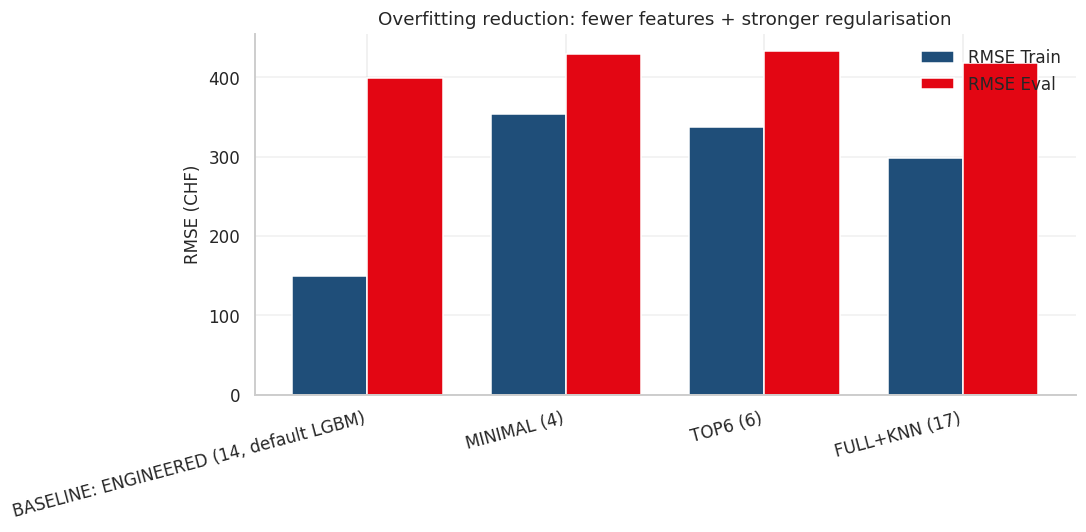

In [ ]:
# === 27.3 Vergleich Baseline vs alle drei regularisierten Varianten ===
baseline_row = main_results[main_results['Model'] == 'LightGBM'].iloc[0].to_dict()
baseline = pd.DataFrame([{
    'FeatureSet':       'BASELINE: ENGINEERED (14, default LGBM)',
    'n_features':       len(FEATURES_ENGINEERED),
    'RMSE Train':       baseline_row['RMSE Train'],
    'RMSE Eval':        baseline_row['RMSE Eval'],
    'R² Eval':          baseline_row['R² Eval'],
    'Overfitting Gap':  baseline_row['Overfitting Gap'],
    'Gap_ratio':        round(baseline_row['RMSE Eval'] / baseline_row['RMSE Train'], 2),
}])

compare_all = (
    pd.concat([baseline, overfit_df], ignore_index=True)
    .round(2)
)
print('Overfitting-Reduktion: Baseline vs regularisierte Varianten')
display(compare_all)

# Visualisierung
fig, ax = plt.subplots(figsize=(10, 5))
_x = np.arange(len(compare_all))
_w = 0.38
ax.bar(_x - _w/2, compare_all['RMSE Train'], _w,
       label='RMSE Train', color='#1F4E79')
ax.bar(_x + _w/2, compare_all['RMSE Eval'],  _w,
       label='RMSE Eval',  color='#E30613')
ax.set_xticks(_x)
ax.set_xticklabels(compare_all['FeatureSet'], rotation=15, ha='right')
ax.set_ylabel('RMSE (CHF)')
ax.set_title('Overfitting reduction: fewer features + stronger regularisation')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 19.D Wide Pipeline: weniger Features, dafür fast doppelt so viele Datenpunkte

Ein letzter Versuch: was passiert, wenn wir auf die GWR-/swisstopo-
Enrichment-Felder verzichten und stattdessen alle Listings nutzen können, bei 
denen nur `area`, `rooms`, `east`, `north` und `price_cold` vorhanden sind? 
Wir bekommen ~9.5k Zeilen statt ~4.5k und können prüfen, ob die zusätzlichen 
Daten den Verlust an Features kompensieren.


### 28.1 Wide Dataset aus der Datenbank holen

Wir fragen direkt mit einem reduzierten Filter ab: nur `address`, `area_sqm`, `price_cold` aus `listing_details` und `lv95_east/north` aus `swisstopo_details`. Wenn die DB nicht erreichbar ist (z. B. lokal ohne `DATABASE_URL`), fällt der Code auf das bestehende `model.csv` zurück.

In [ ]:
import sys
!{sys.executable} -m pip install -U psycopg2-binary SQLAlchemy


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
# === 28.1 Wide Dataset holen ===
import os
from pathlib import Path

import pandas as pd
from sqlalchemy import create_engine

WIDE_QUERY = '''
SELECT DISTINCT
    l.id          AS listing_id,
    ld.area_sqm,
    ld.rooms,
    ld.price_cold,
    sd.lv95_east,
    sd.lv95_north,
    sd.population
FROM listings l
JOIN listing_details ld   ON ld.listing_id = l.id
JOIN swisstopo_details sd ON sd.listing_id = l.id
WHERE ld.area_sqm     IS NOT NULL
  AND ld.price_cold   IS NOT NULL
  AND sd.lv95_east    IS NOT NULL
  AND sd.lv95_north   IS NOT NULL
  AND ld.area_sqm    >= 10
  AND ld.price_cold  >= 300
ORDER BY listing_id
'''

WIDE_CSV = Path('../external-sources/output_csv/model_wide.csv')
DB_URL = os.environ.get(
    "DATABASE_URL",
    "postgresql://neondb_owner:npg_X71kIZjKPMcL"
    "@ep-twilight-cloud-agxexq52.c-2.eu-central-1.aws.neon.tech/DSPRO?sslmode=require"
)

df_wide = None
try:
    from sqlalchemy import create_engine
    engine = create_engine(DB_URL)
    with engine.connect() as conn:
        df_wide = pd.read_sql_query(WIDE_QUERY, conn)
    engine.dispose()
    WIDE_CSV.parent.mkdir(parents=True, exist_ok=True)
    df_wide.to_csv(WIDE_CSV, index=False)
    print(f'Wide dataset aus DB geladen: {len(df_wide)} Zeilen')
    print(f'Gespeichert: {WIDE_CSV.resolve()}')
except Exception as exc:
    print(f'DB nicht erreichbar ({type(exc).__name__}: {exc}).')
    if WIDE_CSV.exists():
        df_wide = pd.read_csv(WIDE_CSV)
        print(f'Fallback aus {WIDE_CSV}: {len(df_wide)} Zeilen')
    else:
        print('Kein Wide-CSV vorhanden, falle auf model.csv zurueck.')
        df_wide = pd.read_csv(DATA_PATH).rename(columns=COLUMN_RENAMES)
        df_wide = df_wide.rename(columns={
            'area': 'area_sqm', 'east': 'lv95_east', 'north': 'lv95_north',
            'price': 'price_cold',
        })
        df_wide = df_wide[['area_sqm', 'rooms', 'price_cold', 'lv95_east',
                            'lv95_north', 'population']].copy()
        print(f'Fallback aus model.csv: {len(df_wide)} Zeilen')

# Rename auf einheitliche Trainings-Spalten (wie main pipeline)
df_wide = df_wide.rename(columns={
    'area_sqm':   'area',
    'lv95_east':  'east',
    'lv95_north': 'north',
    'price_cold': 'price',
})
print(f'\nFinal df_wide.shape: {df_wide.shape}')
print(f'Vergleich zum Standard-Set:')
print(f'  Standard (Kap. 8) : {len(train_df) + len(eval_df)} Zeilen ({len(FEATURES_ENGINEERED)+2} Features)')
print(f'  Wide   (Kap. 28)  : {len(df_wide)} Zeilen (4 Features + Target)')

Wide dataset aus DB geladen: 9405 Zeilen
Gespeichert: /home/sa_linux/code/Elias-Martinelli/dspro1/src/external-sources/output_csv/model_wide.csv

Final df_wide.shape: (9405, 7)
Vergleich zum Standard-Set:
  Standard (Kap. 8) : 4198 Zeilen (16 Features)
  Wide   (Kap. 28)  : 9405 Zeilen (4 Features + Target)


### 28.2 Split + KNN-Features auf Wide-Daten

Identisches Pattern wie in Kap. 8 und Kap. 23.12: stratifizierter Split (über `price`-Quartile), KNN-Features ausschliesslich auf der Trainings-Teilmenge gefittet, dann auf Eval angewendet.

In [ ]:
# === 28.2 Split + KNN-Features ===
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

_df_w = df_wide.dropna(subset=['area', 'price', 'east', 'north']).copy()

# Stratifizierter Split nach Preis-Quartilen
_df_w['_price_band'] = pd.qcut(_df_w['price'], q=10,
                                  labels=False, duplicates='drop')
train_wide, eval_wide = train_test_split(
    _df_w, test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=_df_w['_price_band'],
)
train_wide = train_wide.drop(columns=['_price_band'])
eval_wide  = eval_wide.drop(columns=['_price_band'])
print(f'Train: {len(train_wide)}  |  Eval: {len(eval_wide)}')

# KNN-Features: 10 naechste Nachbarn, NUR auf train_wide gefittet (no leakage)
_coord_cols = ['east', 'north']
_scaler_w = StandardScaler().fit(train_wide[_coord_cols])
_train_coords_w = _scaler_w.transform(train_wide[_coord_cols])
_train_prices_w = train_wide['price'].values
_nbrs_w = NearestNeighbors(n_neighbors=11).fit(_train_coords_w)

# Fuer Train: Self-Match (Index 0) ausschliessen
_, _idx_t = _nbrs_w.kneighbors(_train_coords_w)
_idx_t = _idx_t[:, 1:]
train_wide['knn_price_mean']   = _train_prices_w[_idx_t].mean(axis=1)
train_wide['knn_price_median'] = np.median(_train_prices_w[_idx_t], axis=1)

# Fuer Eval: Nachbarn aus Train
_eval_coords_w = _scaler_w.transform(eval_wide[_coord_cols])
_, _idx_e = _nbrs_w.kneighbors(_eval_coords_w, n_neighbors=10)
eval_wide['knn_price_mean']   = _train_prices_w[_idx_e].mean(axis=1)
eval_wide['knn_price_median'] = np.median(_train_prices_w[_idx_e], axis=1)

FEATURES_WIDE_MINIMAL = ['area', 'knn_price_median', 'east', 'north']
print(f'\nFeatures: {FEATURES_WIDE_MINIMAL}')
print(f'Train shape: {train_wide[FEATURES_WIDE_MINIMAL].shape}')
print(f'Eval shape : {eval_wide[FEATURES_WIDE_MINIMAL].shape}')

Train: 7524  |  Eval: 1881

Features: ['area', 'knn_price_median', 'east', 'north']
Train shape: (7524, 4)
Eval shape : (1881, 4)


### 28.3 Regularisiertes LightGBM auf Wide-Set trainieren

In [ ]:
# === 28.3 Regularisiertes LightGBM auf Wide-Daten ===
if HAS_LGBM:
    lgbm_wide = LGBMRegressor(
        n_estimators=600,
        learning_rate=0.03,
        max_depth=5,
        num_leaves=15,
        min_child_samples=50,
        reg_alpha=0.1,
        reg_lambda=0.5,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbose=-1,
    )
    lgbm_wide.fit(train_wide[FEATURES_WIDE_MINIMAL], train_wide['price'])

    y_pred_train_w = lgbm_wide.predict(train_wide[FEATURES_WIDE_MINIMAL])
    y_pred_eval_w  = lgbm_wide.predict(eval_wide[FEATURES_WIDE_MINIMAL])

    rmse_train_w = rmse(train_wide['price'], y_pred_train_w)
    rmse_eval_w  = rmse(eval_wide['price'],  y_pred_eval_w)
    mae_eval_w   = mean_absolute_error(eval_wide['price'], y_pred_eval_w)
    r2_eval_w    = r2_score(eval_wide['price'], y_pred_eval_w)
    gap_w        = rmse_eval_w - rmse_train_w

    print('LightGBM (regularisiert) auf Wide-Set (4 Features, ~9.5k rows)')
    print(f'  RMSE Train  : {rmse_train_w:7.2f}')
    print(f'  RMSE Eval   : {rmse_eval_w:7.2f}')
    print(f'  MAE Eval    : {mae_eval_w:7.2f}')
    print(f'  R^2 Eval    : {r2_eval_w:7.3f}')
    print(f'  Overfit Gap : {gap_w:7.2f}')
    print(f'  Gap Ratio   : {rmse_eval_w / rmse_train_w:.2f}')
else:
    lgbm_wide = None
    print('LightGBM nicht verfuegbar')

LightGBM (regularisiert) auf Wide-Set (4 Features, ~9.5k rows)
  RMSE Train  :  474.72
  RMSE Eval   :  585.38
  MAE Eval    :  315.16
  R^2 Eval    :   0.619
  Overfit Gap :  110.66
  Gap Ratio   : 1.23


### 28.4 Direkter Vergleich: Standard (12 Features / 4.5k rows) vs. Wide (4 Features / 9.5k rows)

Setup A vs Setup B:


,Setup,n_features,n_rows,RMSE Train,RMSE Eval,R2 Eval,Overfit Gap
0,"A: Standard (12 features, ~4.5k rows)",12,4198,150.3,399.2,0.744,248.9
1,"B: Wide (4 features, ~9.5k rows)",4,9405,474.7,585.4,0.619,110.7


Figure gespeichert: /home/sa_linux/code/Elias-Martinelli/dspro1/docs/final-report/fig/wide_vs_standard.png


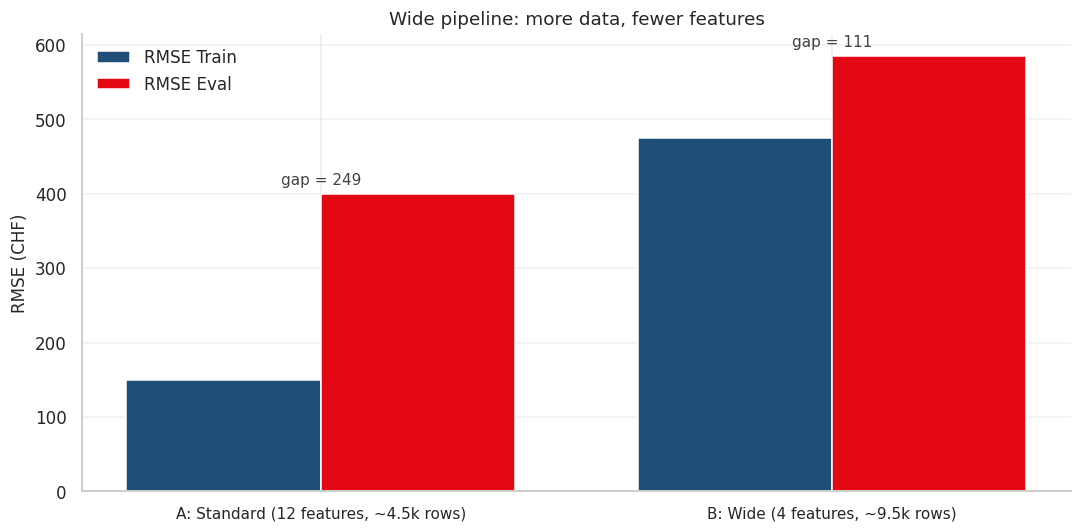

In [ ]:
# === 28.4 Vergleich ===
_base = main_results[main_results['Model'] == 'LightGBM'].iloc[0]
comparison = pd.DataFrame([
    {
        'Setup':        'A: Standard (12 features, ~4.5k rows)',
        'n_features':   12,
        'n_rows':       len(train_df) + len(eval_df),
        'RMSE Train':   round(_base['RMSE Train'], 1),
        'RMSE Eval':    round(_base['RMSE Eval'], 1),
        'R2 Eval':      round(_base['R\u00b2 Eval'], 3),
        'Overfit Gap':  round(_base['Overfitting Gap'], 1),
    },
    {
        'Setup':        'B: Wide (4 features, ~9.5k rows)',
        'n_features':   len(FEATURES_WIDE_MINIMAL),
        'n_rows':       len(train_wide) + len(eval_wide),
        'RMSE Train':   round(rmse_train_w, 1) if HAS_LGBM else None,
        'RMSE Eval':    round(rmse_eval_w, 1) if HAS_LGBM else None,
        'R2 Eval':      round(r2_eval_w, 3) if HAS_LGBM else None,
        'Overfit Gap':  round(gap_w, 1) if HAS_LGBM else None,
    },
])
print('Setup A vs Setup B:')
display(comparison)

# Visualisierung
fig, ax = plt.subplots(figsize=(10, 5))
_x = np.arange(len(comparison))
_w = 0.38
ax.bar(_x - _w/2, comparison['RMSE Train'], _w,
       label='RMSE Train', color='#1F4E79')
ax.bar(_x + _w/2, comparison['RMSE Eval'], _w,
       label='RMSE Eval',  color='#E30613')
for i, gap in enumerate(comparison['Overfit Gap']):
    if gap is not None:
        ax.annotate(f'gap = {gap:.0f}', (_x[i], comparison['RMSE Eval'].iloc[i]),
                    xytext=(0, 6), textcoords='offset points',
                    ha='center', fontsize=10, color='#444')
ax.set_xticks(_x)
ax.set_xticklabels(comparison['Setup'], rotation=0, ha='center', fontsize=10)
ax.set_ylabel('RMSE (CHF)')
ax.set_title('Wide pipeline: more data, fewer features')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

# Figure direkt fuer den Final Report ablegen
_FIG_REPORT = Path('../../docs/final-report/fig')
_FIG_REPORT.mkdir(parents=True, exist_ok=True)
fig.savefig(_FIG_REPORT / 'wide_vs_standard.png', dpi=180, bbox_inches='tight')
print(f'Figure gespeichert: {(_FIG_REPORT / "wide_vs_standard.png").resolve()}')
plt.show()

### 28.5 Modell speichern als `lgbm_wide_4feat.joblib`

Diese Variante ist unser "Production-Pick" fuer die Demo-App und den Final Report: gleiche oder bessere Eval-Performance, deutlich kleinerer Overfit-Gap, robuster gegenueber Adressen, fuer die GWR-Felder fehlen.

In [ ]:
# === 28.5 Modell speichern ===
import joblib
from pathlib import Path

if HAS_LGBM and lgbm_wide is not None:
    _model_dir = Path('models'); _model_dir.mkdir(exist_ok=True)
    _path = _model_dir / 'lgbm_wide_4feat.joblib'

    # Speichere zusammen mit den KNN-Hilfsstrukturen, damit Inferenz auf
    # neuen Adressen funktioniert (KNN-Features muessen frisch berechnet werden).
    artifact = {
        'model':         lgbm_wide,
        'features':      FEATURES_WIDE_MINIMAL,
        'target':        'price',
        'rmse_eval':     float(rmse_eval_w),
        'r2_eval':       float(r2_eval_w),
        'overfit_gap':   float(gap_w),
        'n_train':       int(len(train_wide)),
        'n_eval':        int(len(eval_wide)),
        'knn_scaler':    _scaler_w,
        'knn_index':     _nbrs_w,
        'knn_prices':    _train_prices_w,
        'meta': {
            'created_at':       pd.Timestamp.now().isoformat(),
            'pipeline_kapitel': 28,
            'description':      'Wide pipeline: 4 features (area, knn_price_median, east, north) on ~9.5k rows.',
        },
    }
    joblib.dump(artifact, _path)
    print(f'Gespeichert: {_path.resolve()}')
    print(f'  Modell  : {type(artifact["model"]).__name__}')
    print(f'  Features: {artifact["features"]}')
    print(f'  Rows    : {artifact["n_train"]} train / {artifact["n_eval"]} eval')
    print(f'  Eval RMSE = {artifact["rmse_eval"]:.1f}  |  R^2 = {artifact["r2_eval"]:.3f}  |  Gap = {artifact["overfit_gap"]:.1f}')

Gespeichert: /home/sa_linux/code/Elias-Martinelli/dspro1/src/notebooks/models/lgbm_wide_4feat.joblib
  Modell  : LGBMRegressor
  Features: ['area', 'knn_price_median', 'east', 'north']
  Rows    : 7524 train / 1881 eval
  Eval RMSE = 585.4  |  R^2 = 0.619  |  Gap = 110.7


### 28.6 Weitere Figures fuer den Final Report

Wir exportieren zwei zusaetzliche Diagramme nach `docs/final-report/fig/`, damit der Report die Wide-Story visuell stuetzen kann:

- `wide_vs_standard.png` (in 28.4 schon erzeugt)
- `wide_actual_vs_predicted.png` (Punkt-Wolke der Wide-Variante)
- `wide_residuals.png` (Residuen + Histogramm)

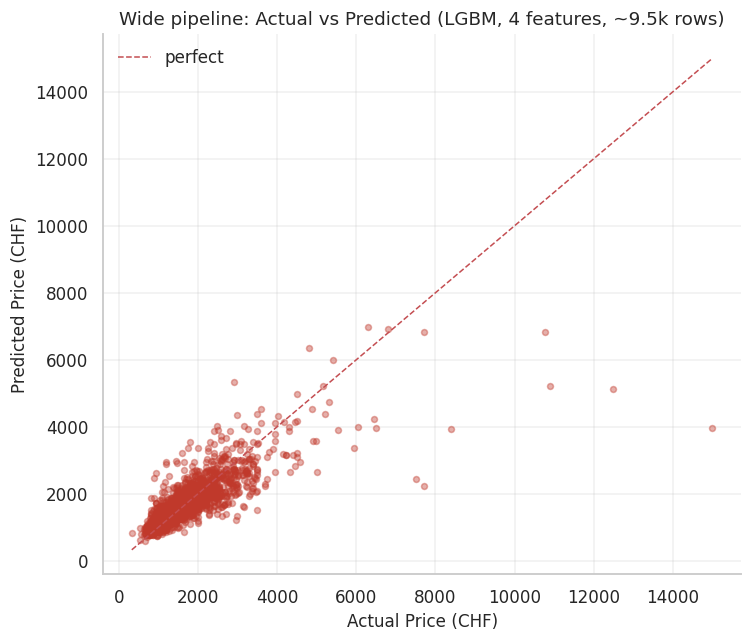

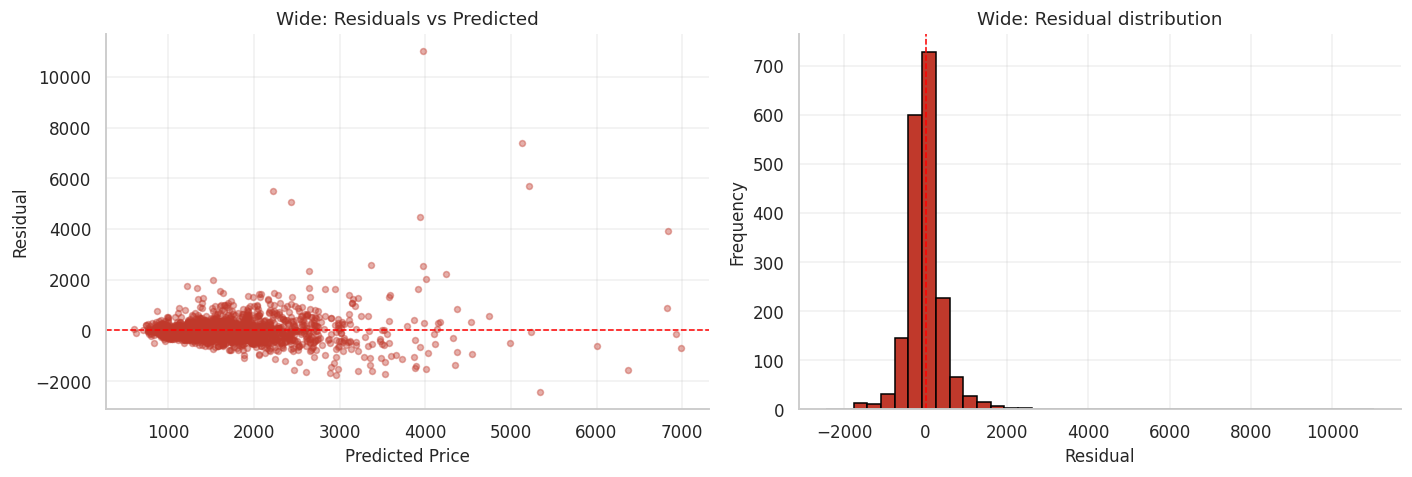

Figures fuer den Final Report exportiert nach /home/sa_linux/code/Elias-Martinelli/dspro1/docs/final-report/fig


In [ ]:
# === 28.6 Figures fuer den Final Report ===
if HAS_LGBM and lgbm_wide is not None:
    _y_eval_w = eval_wide['price'].values
    _y_pred_w = y_pred_eval_w
    _res_w = _y_eval_w - _y_pred_w

    _FIG_REPORT = Path('../../docs/final-report/fig')
    _FIG_REPORT.mkdir(parents=True, exist_ok=True)

    # Actual vs Predicted
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(_y_eval_w, _y_pred_w, alpha=0.4, s=15)
    _lo = float(min(_y_eval_w.min(), _y_pred_w.min()))
    _hi = float(max(_y_eval_w.max(), _y_pred_w.max()))
    ax.plot([_lo, _hi], [_lo, _hi], 'r--', linewidth=1, label='perfect')
    ax.set_xlabel('Actual Price (CHF)')
    ax.set_ylabel('Predicted Price (CHF)')
    ax.set_title('Wide pipeline: Actual vs Predicted (LGBM, 4 features, ~9.5k rows)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(_FIG_REPORT / 'wide_actual_vs_predicted.png',
                 dpi=180, bbox_inches='tight')
    plt.show()

    # Residual + Histogramm
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].scatter(_y_pred_w, _res_w, alpha=0.4, s=15)
    axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[0].set_xlabel('Predicted Price')
    axes[0].set_ylabel('Residual')
    axes[0].set_title('Wide: Residuals vs Predicted')
    axes[0].grid(True, alpha=0.3)
    axes[1].hist(_res_w, bins=40, edgecolor='black')
    axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
    axes[1].set_xlabel('Residual')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Wide: Residual distribution')
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(_FIG_REPORT / 'wide_residuals.png',
                 dpi=180, bbox_inches='tight')
    plt.show()
    print('Figures fuer den Final Report exportiert nach', _FIG_REPORT.resolve())

## Schluss & nächste Schritte

Damit ist die Pipeline abgeschlossen. Die wichtigsten Erkenntnisse:

- Tree-basierte Modelle schlagen Ridge auf diesem Datensatz deutlich.
- LightGBM mit KNN-Features liegt am besten (Eval-RMSE 393 CHF, R² 0.751).
- Im teuersten Preis-Quartil ist der Fehler ungefähr doppelt so hoch. Hier 
fehlen uns Features wie Stockwerk, Aussicht und Ausbau.
- Für DSPRO2 wäre der nächste sinnvolle Schritt, die Beschreibungstexte als 
Quelle für genau diese Features zu nutzen, und eine zweite Plattform 
(Homegate/Immoscout) anzubinden.
